# Exploratory Data Analysis & Data Cleaning
## Oil Shocks & Capital Reallocation Toward Green Firms

**Event:** US–Israel military strikes on Iran — 2026-02-28  
**First trading day:** 2026-03-02  
**Sample:** 2021-01-01 → 2026-04-20  
**Universe:** Green and brown firms + ETFs

---



##  Setup

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera, shapiro, normaltest
from statsmodels.tsa.stattools import acf, pacf, q_stat
from statsmodels.stats.stattools import durbin_watson

plt.rcParams.update({
    "figure.dpi": 150, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

GREEN  = "#337a7a"
BROWN  = "#6a5048"
GREY   = "#777777"
BLUE   = "#4b86b4"
RED    = "#c0392b"

BASE_DIR  = Path.cwd()
CLEAN_DIR = BASE_DIR / "../data/clean"
FIG_DIR   = BASE_DIR / "../figures/eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EVENT_DATE = pd.Timestamp("2026-03-02")

KEY_COLS = [
    "close", "open", "high", "low", "volume",
    "turnover", "log_return", "market_cap", "shares_out", "parkinson_vol",
]

In [4]:
firm_panel = pd.read_csv(CLEAN_DIR / "firm_panel_final.csv", parse_dates=["date"])
etf_panel  = pd.read_csv(CLEAN_DIR / "etf_panel_final.csv",  parse_dates=["date"])

# Drop uninformative column immediately — it is empty in all rows
firm_panel = firm_panel.drop(columns=["brent_turnover"], errors="ignore")
etf_panel  = etf_panel.drop(columns=["brent_turnover"], errors="ignore")

for df, label, gc in [
    (firm_panel, "FIRM PANEL", "energy_type"),
    (etf_panel,  "ETF PANEL",  "asset_group"),
]:
    df.sort_values(["ric", "date"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"{label}")
    print(f"  Shape        : {df.shape}")
    print(f"  Columns      : {list(df.columns)}")
    print(f"  Date range   : {df['date'].min().date()} → "
          f"{df['date'].max().date()}")
    print(f"  Unique dates : {df['date'].nunique()}")
    print(f"  Unique RICs  : {df['ric'].nunique()}")
    print()

FIRM PANEL
  Shape        : (437873, 42)
  Columns      : ['date', 'open', 'high', 'low', 'close', 'volume', 'turnover', 'market_cap', 'ric', 'company_name', 'energy_type', 'green_dummy', 'log_return', 'simple_return', 'traded_value', 'log_hl_range', 'parkinson_vol', 'shares_out', 'vix_close', 'ovx_close', 'Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'brent_close', 'natural_gas_close', 'wti_close', 'brent_log_return', 'natural_gas_log_return', 'wti_log_return', 'brent_parkinson_vol', 'natural_gas_parkinson_vol', 'wti_parkinson_vol', 'brent_simple_return', 'natural_gas_simple_return', 'wti_simple_return', 'brent_volume', 'natural_gas_volume', 'wti_volume', 'excess_return']
  Date range   : 2016-09-15 → 2026-08-28
  Unique dates : 1434
  Unique RICs  : 335

ETF PANEL
  Shape        : (42600, 41)
  Columns      : ['date', 'open', 'high', 'low', 'close', 'volume', 'turnover', 'market_cap', 'ric', 'asset_group', 'log_return', 'simple_return', 'traded_value', 'log_hl_range', 'parkinson_vol', 

## Group Label


In [5]:
for panel, gc, label in [
    (firm_panel, "energy_type", "FIRMS"),
    (etf_panel,  "asset_group", "ETFs"),
]:
    print(f"\n{'━'*60}  {label}")

    # Label distribution
    print(f"\n  Label distribution (including NaN):")
    print(panel[gc].value_counts(dropna=False).to_string())

    # Rows with missing label
    missing = panel[panel[gc].isna()]
    print(f"\n  Rows with missing {gc} : {len(missing):,}")
    if not missing.empty:
        print(f"  Distinct RICs        : {missing['ric'].nunique()}")
        print(f"\n  RICs and row counts:")
        print(missing["ric"].value_counts().to_string())

    # RICs under more than one label
    multi = (panel.groupby("ric")[gc]
                  .nunique()
                  .pipe(lambda s: s[s > 1]))
    print(f"\n  RICs with multiple {gc} values : {len(multi)}")
    if not multi.empty:
        for ric in multi.index:
            print(f"    {ric} : "
                  f"{panel[panel['ric']==ric][gc].unique()}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  FIRMS

  Label distribution (including NaN):
energy_type
brown    240986
green    192627
NaN        4260

  Rows with missing energy_type : 4,260
  Distinct RICs        : 3

  RICs and row counts:
ric
CMS_PB.N     1420
GLOP_PA.N    1420
SEAL_PB.N    1420

  RICs with multiple energy_type values : 0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ETFs

  Label distribution (including NaN):
asset_group
brown    25560
green    17040

  Rows with missing asset_group : 0

  RICs with multiple asset_group values : 0


In [6]:
unlabelled = firm_panel[firm_panel["energy_type"].isna()]["ric"].unique()

print(f"Unlabelled RICs in firm panel: {len(unlabelled)}")

for ric in unlabelled:
    sub  = firm_panel[firm_panel["ric"] == ric]
    base = ric.split("_")[0].split(".")[0]
    siblings = firm_panel[
        firm_panel["ric"].str.startswith(base) &
        firm_panel["energy_type"].notna()
    ]["ric"].unique()

    print(f"\n  ── {ric} ──")
    print(f"    Rows        : {len(sub)}")
    print(f"    Date range  : {sub['date'].min().date()} → "
          f"{sub['date'].max().date()}")
    if "close" in sub.columns:
        print(f"    Close       : min={sub['close'].min():.2f}  "
              f"mean={sub['close'].mean():.2f}  "
              f"max={sub['close'].max():.2f}")
    if "volume" in sub.columns:
        print(f"    Avg volume  : {sub['volume'].mean():.0f}")
    if "company_name" in sub.columns:
        print(f"    Name        : "
              f"{sub['company_name'].dropna().unique()}")
    if len(siblings):
        print(f"    Base ticker matches labelled RIC(s): {siblings}")

Unlabelled RICs in firm panel: 3

  ── CMS_PB.N ──
    Rows        : 1420
    Date range  : 2021-01-04 → 2026-08-28
    Close       : min=73.76  mean=89.39  max=112.50
    Avg volume  : 132
    Name        : []

  ── GLOP_PA.N ──
    Rows        : 1420
    Date range  : 2021-01-04 → 2026-08-28
    Close       : min=16.51  mean=24.77  max=26.50
    Avg volume  : 2560
    Name        : []

  ── SEAL_PB.N ──
    Rows        : 1420
    Date range  : 2021-01-04 → 2026-08-28
    Close       : min=20.30  mean=25.30  max=27.81
    Avg volume  : 3206
    Name        : []


In [7]:
before_g = firm_panel[firm_panel["energy_type"]=="green"]["ric"].nunique()
before_b = firm_panel[firm_panel["energy_type"]=="brown"]["ric"].nunique()
before_rows = len(firm_panel)

drop_rics = firm_panel[firm_panel["energy_type"].isna()]["ric"].unique()
firm_panel = (firm_panel[~firm_panel["ric"].isin(drop_rics)]
              .copy().reset_index(drop=True))

after_g = firm_panel[firm_panel["energy_type"]=="green"]["ric"].nunique()
after_b = firm_panel[firm_panel["energy_type"]=="brown"]["ric"].nunique()

print(f"Dropped {len(drop_rics)} unlabelled RIC(s): {list(drop_rics)}")
print(f"Rows   : {before_rows:,} → {len(firm_panel):,}")
print(f"Green  : {before_g} → {after_g}")
print(f"Brown  : {before_b} → {after_b}")
print(f"Remaining missing energy_type: "
      f"{firm_panel['energy_type'].isna().sum()} ✓")

Dropped 3 unlabelled RIC(s): ['CMS_PB.N', 'GLOP_PA.N', 'SEAL_PB.N']
Rows   : 437,873 → 433,613
Green  : 147 → 147
Brown  : 185 → 185
Remaining missing energy_type: 0 ✓


## 3. Date Coverage — Holiday Rows

In [8]:
def build_nyse_holidays(years):
    holidays = []
    for y in years:
        sep1      = pd.Timestamp(f"{y}-09-01")
        labor_day = sep1 + pd.offsets.Week(weekday=0)
        if labor_day.month != 9: labor_day = sep1
        holidays.append(labor_day)
        if y >= 2022:
            jun19 = pd.Timestamp(f"{y}-06-19")
            if jun19.weekday() == 5: jun19 -= pd.Timedelta(days=1)
            elif jun19.weekday() == 6: jun19 += pd.Timedelta(days=1)
            holidays.append(jun19)
        for m, d in [(1,1),(1,20),(2,17),(5,26),(7,4),(11,27),(12,25)]:
            try:
                h = pd.Timestamp(f"{y}-{m:02d}-{d:02d}")
                if h.weekday() == 5: h -= pd.Timedelta(days=1)
                if h.weekday() == 6: h += pd.Timedelta(days=1)
                holidays.append(h)
            except Exception:
                pass
    hset        = pd.DatetimeIndex(sorted(set(holidays)))
    # Christmas Eve early-close days are real trading days — keep them
    early_close = pd.to_datetime(["2024-12-24","2025-12-24","2026-12-24"])
    return hset[~hset.isin(early_close)]

NYSE_HOLIDAYS = build_nyse_holidays(range(2021, 2027))
print(f"NYSE holidays identified: {len(NYSE_HOLIDAYS)}")
print(pd.Series(NYSE_HOLIDAYS).dt.date.values)

NYSE holidays identified: 53
[datetime.date(2021, 1, 1) datetime.date(2021, 1, 20)
 datetime.date(2021, 2, 17) datetime.date(2021, 5, 26)
 datetime.date(2021, 7, 5) datetime.date(2021, 9, 6)
 datetime.date(2021, 11, 26) datetime.date(2021, 12, 24)
 datetime.date(2021, 12, 31) datetime.date(2022, 1, 20)
 datetime.date(2022, 2, 17) datetime.date(2022, 5, 26)
 datetime.date(2022, 6, 20) datetime.date(2022, 7, 4)
 datetime.date(2022, 9, 5) datetime.date(2022, 11, 28)
 datetime.date(2022, 12, 26) datetime.date(2023, 1, 2)
 datetime.date(2023, 1, 20) datetime.date(2023, 2, 17)
 datetime.date(2023, 5, 26) datetime.date(2023, 6, 19)
 datetime.date(2023, 7, 4) datetime.date(2023, 9, 4)
 datetime.date(2023, 11, 27) datetime.date(2023, 12, 25)
 datetime.date(2024, 1, 1) datetime.date(2024, 1, 19)
 datetime.date(2024, 2, 16) datetime.date(2024, 5, 27)
 datetime.date(2024, 6, 19) datetime.date(2024, 7, 4)
 datetime.date(2024, 9, 2) datetime.date(2024, 11, 27)
 datetime.date(2024, 12, 25) datetime.d

In [9]:
for panel, label in [(firm_panel,"FIRMS"), (etf_panel,"ETFs")]:
    unique_dates = pd.DatetimeIndex(sorted(panel["date"].unique()))

    # Weekend rows
    weekends = unique_dates[unique_dates.weekday >= 5]
    print(f"\n{'━'*60}  {label}")
    print(f"  Weekend dates in panel : {len(weekends)}"
          + (f"  not ok" if len(weekends) else "  ok"))
    if len(weekends):
        for d in weekends:
            print(f"    {d.date()}  "
                  f"({(panel['date']==d).sum()} rows)")

    # Holiday rows
    hol_in_panel = unique_dates[unique_dates.isin(NYSE_HOLIDAYS)]
    print(f"  Holiday dates present  : {len(hol_in_panel)}"
          + (f"  not ok" if len(hol_in_panel) else "  ok"))
    if len(hol_in_panel):
        for d in hol_in_panel:
            print(f"    {d.date()}  "
                  f"({(panel['date']==d).sum()} rows)")

    # Missing business days
    bdays   = pd.bdate_range(unique_dates.min(), unique_dates.max())
    bdays   = bdays[~bdays.isin(NYSE_HOLIDAYS)]
    missing = bdays[~bdays.isin(unique_dates)]
    print(f"  Expected business days : {len(bdays)}")
    print(f"  Missing business days  : {len(missing)}"
          + ("ok" if len(missing)==0 else "  not ok"))
    if 0 < len(missing) <= 20:
        print(f"    {[str(d.date()) for d in missing]}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  FIRMS
  Weekend dates in panel : 4  not ok
    2021-09-05  (1 rows)
    2021-09-19  (1 rows)
    2021-09-26  (1 rows)
    2023-09-10  (1 rows)
  Holiday dates present  : 24  not ok
    2021-01-20  (263 rows)
    2021-02-17  (267 rows)
    2021-05-26  (278 rows)
    2021-11-26  (289 rows)
    2021-12-24  (8 rows)
    2021-12-31  (291 rows)
    2022-01-20  (295 rows)
    2022-02-17  (295 rows)
    2022-05-26  (295 rows)
    2022-06-20  (1 rows)
    2022-11-28  (298 rows)
    2023-01-20  (298 rows)
    2023-02-17  (300 rows)
    2023-05-26  (301 rows)
    2023-11-27  (307 rows)
    2024-01-19  (307 rows)
    2024-02-16  (307 rows)
    2024-06-19  (1 rows)
    2024-11-27  (316 rows)
    2025-06-19  (1 rows)
    2025-09-08  (325 rows)
    2026-01-20  (323 rows)
    2026-02-17  (325 rows)
    2026-05-26  (325 rows)
  Expected business days : 2547
  Missing business days  : 1141  not ok

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [10]:
for name in ["firm_panel", "etf_panel"]:
    panel  = eval(name)
    before = len(panel)
    panel  = panel[~panel["date"].isin(NYSE_HOLIDAYS)].copy().reset_index(drop=True)
    print(f"{name}: {before - len(panel):,} holiday rows removed  "
          f"({before:,} → {len(panel):,})")
    exec(f"{name} = panel")

firm_panel: 6,016 holiday rows removed  (433,613 → 427,597)
etf_panel: 600 holiday rows removed  (42,600 → 42,000)


## 4. Firm Activity — History Length



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  FIRMS

  Firms by year of first valid close:
first_year  2021.0  2022.0  2023.0  2024.0  2025.0  2026.0
group                                                     
brown          148       3       8       6       9       3
green          111       5       3       5       4       2

  Not active before 2024-01-01 : 54
    ric group first_close last_close  n_rows  pct_miss_close
  TBN.N brown  2024-06-27 2026-08-28    1260            57.1
   LB.N brown  2024-06-28 2026-08-28     539             0.0
  BKV.N brown  2024-09-26 2026-08-28     477             0.0
  FTW.N brown  2024-09-27 2026-08-28     512             7.6
PTLE.OQ brown  2024-10-16 2026-08-28     463             0.0
 LSE.OQ brown  2024-12-19 2026-08-28     419             0.0
 UFG.OQ brown  2025-01-14 2026-08-28     404             0.0
 FLOC.N brown  2025-01-16 2026-08-28     402             0.0
   VG.N brown  2025-01-24 2026-08-28     397             0.0
  INR.N b

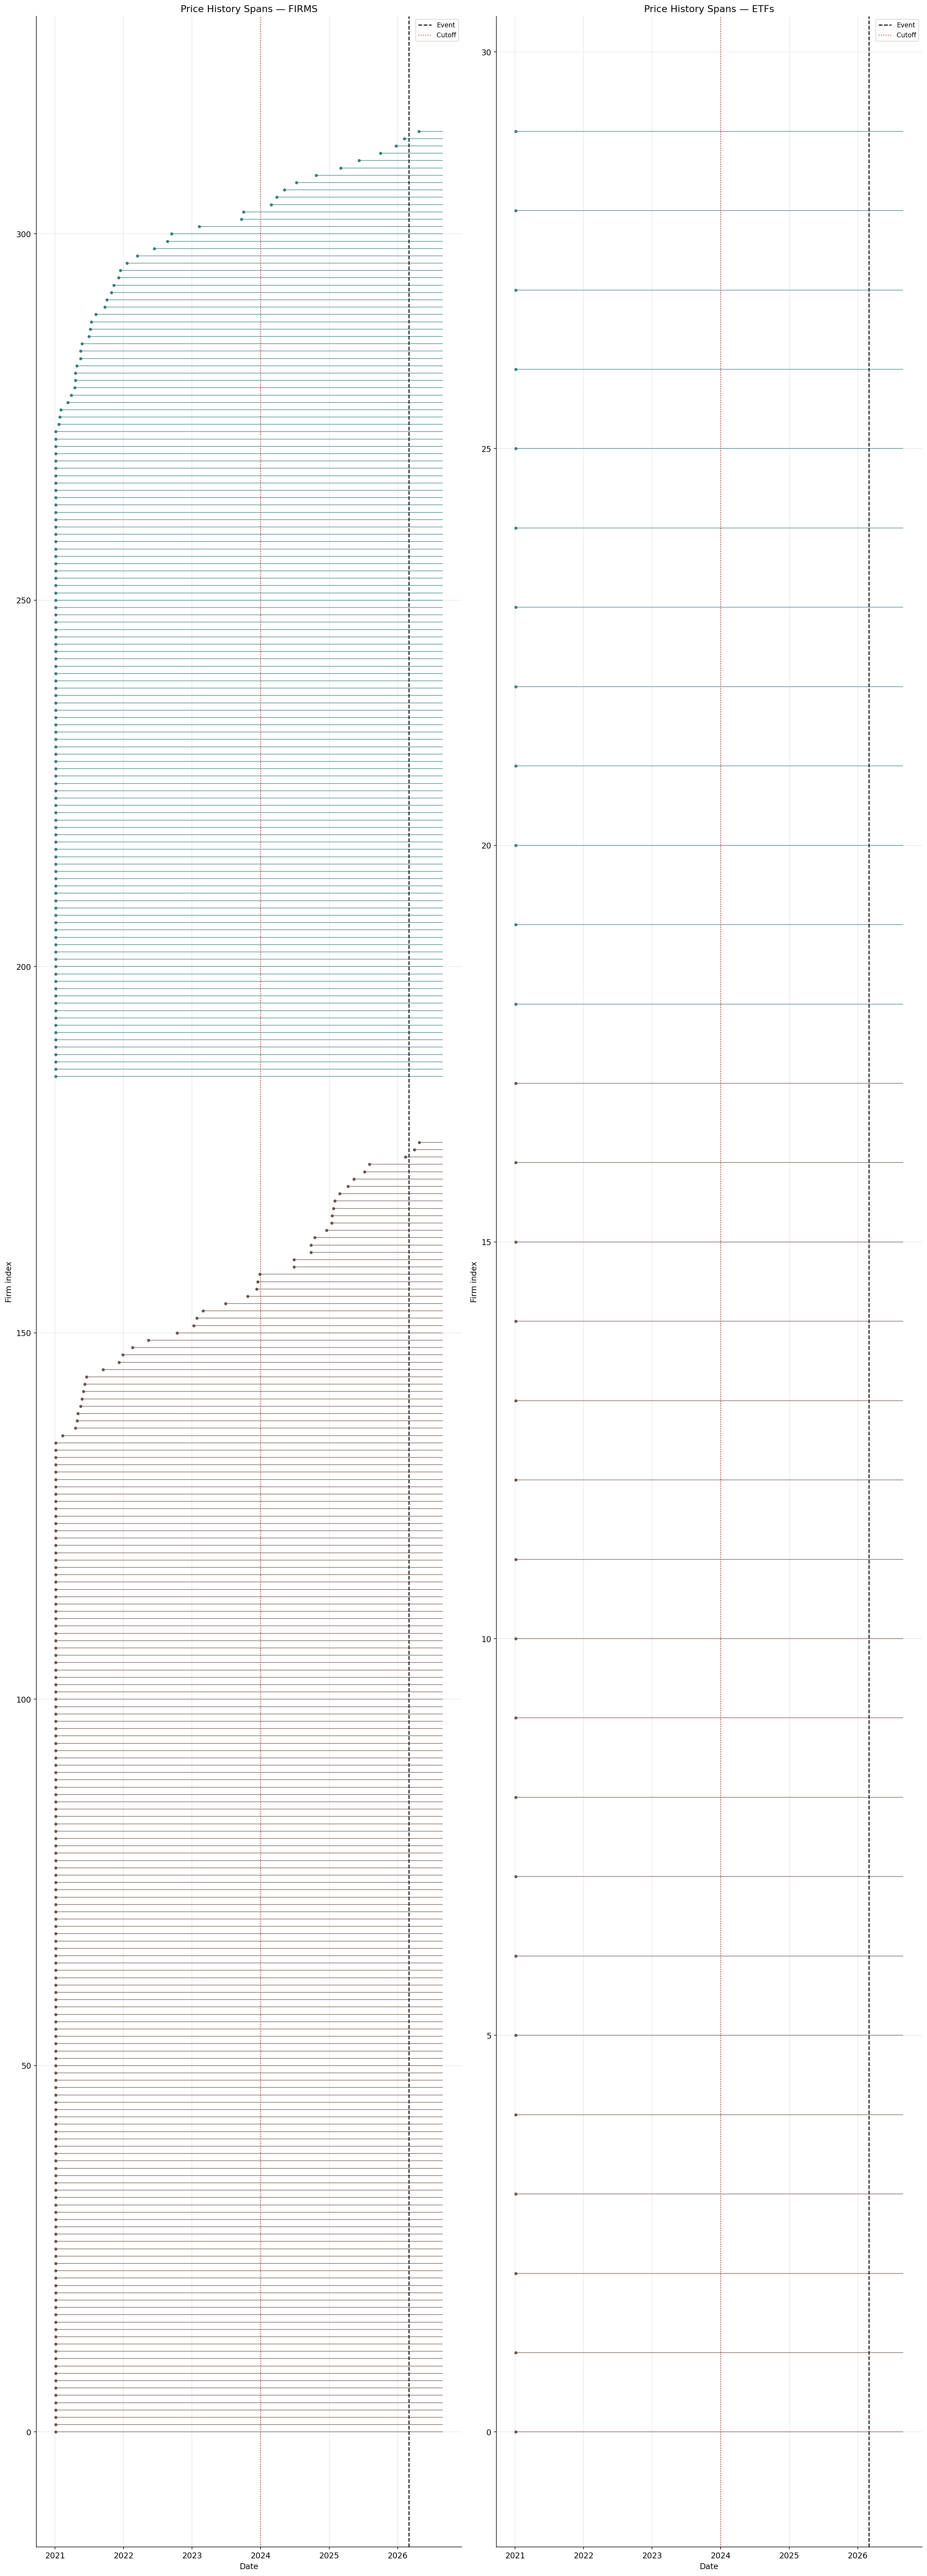

In [11]:
def firm_activity(panel, gc):
    rows = []
    for ric, grp in panel.groupby("ric"):
        gc_val      = grp[gc].dropna().iloc[0] \
                      if grp[gc].notna().any() else "unlabelled"
        first_close = grp.loc[grp["close"].notna(), "date"].min() \
                      if "close" in grp.columns else pd.NaT
        last_close  = grp.loc[grp["close"].notna(), "date"].max() \
                      if "close" in grp.columns else pd.NaT
        n_rows      = len(grp)
        n_close     = grp["close"].count() if "close" in grp.columns else 0
        rows.append({
            "ric": ric, "group": gc_val,
            "first_close": first_close, "last_close": last_close,
            "n_rows": n_rows, "n_close": n_close,
            "pct_miss_close": round((1 - n_close/n_rows)*100, 1),
        })
    return pd.DataFrame(rows)


ACTIVE_CUTOFF = pd.Timestamp("2024-01-01")

for panel, gc, label in [
    (firm_panel, "energy_type", "FIRMS"),
    (etf_panel,  "asset_group", "ETFs"),
]:
    act = firm_activity(panel, gc)
    print(f"\n{'━'*60}  {label}")

    # Distribution of first close by year
    act["first_year"] = pd.to_datetime(act["first_close"]).dt.year
    print(f"\n  Firms by year of first valid close:")
    print(act.groupby(["group","first_year"])["ric"]
              .count().unstack(fill_value=0).to_string())

    # Firms not active before cutoff
    late = act[
        act["first_close"].isna() |
        (act["first_close"] >= ACTIVE_CUTOFF)
    ].sort_values(["group","first_close"])

    print(f"\n  Not active before {ACTIVE_CUTOFF.date()} : {len(late)}")
    if not late.empty:
        print(late[["ric","group","first_close",
                     "last_close","n_rows","pct_miss_close"]]
              .to_string(index=False))

# Timeline plot — shows all firms' price spans at a glance
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(firm_panel["ric"].unique())*0.15)))
for ax, panel, gc, label in [
    (axes[0], firm_panel, "energy_type", "FIRMS"),
    (axes[1], etf_panel,  "asset_group", "ETFs"),
]:
    act = firm_activity(panel, gc).sort_values(["group","first_close"]).reset_index(drop=True)
    for i, row in act.iterrows():
        color = GREEN if row["group"]=="green" else \
                BROWN if row["group"]=="brown" else GREY
        if not pd.isna(row["first_close"]) and not pd.isna(row["last_close"]):
            ax.plot([row["first_close"], row["last_close"]], [i, i],
                    color=color, lw=1, alpha=0.7)
            ax.scatter(row["first_close"], i, color=color, s=10, zorder=3)
    ax.axvline(EVENT_DATE,    color="black", lw=1.4, ls="--", label="Event")
    ax.axvline(ACTIVE_CUTOFF, color=RED,     lw=1.2, ls=":",  label="Cutoff")
    ax.set_title(f"Price History Spans — {label}")
    ax.set_xlabel("Date"); ax.set_ylabel("Firm index")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR/"firm_activity.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
for name, gc in [("firm_panel","energy_type"), ("etf_panel","asset_group")]:
    panel  = eval(name)
    act    = firm_activity(panel, gc)
    drop   = act[
        act["first_close"].isna() |
        (act["first_close"] >= ACTIVE_CUTOFF)
    ]["ric"].tolist()

    before_g = panel[panel[gc]=="green"]["ric"].nunique()
    before_b = panel[panel[gc]=="brown"]["ric"].nunique()

    if drop:
        panel = (panel[~panel["ric"].isin(drop)]
                 .copy().reset_index(drop=True))
        after_g = panel[panel[gc]=="green"]["ric"].nunique()
        after_b = panel[panel[gc]=="brown"]["ric"].nunique()
        print(f"{name}: dropped {len(drop)} RIC(s) not active after "
              f"{ACTIVE_CUTOFF.date()}")
        for r in drop:
            print(f"  {r}")
        print(f"  Green: {before_g}→{after_g}  Brown: {before_b}→{after_b}")
    else:
        print(f"{name}: all firms active after cutoff ")

    exec(f"{name} = panel")

firm_panel: dropped 54 RIC(s) not active after 2024-01-01
  ADN.O
  AMPS.N
  APC.OQ
  BKV.N
  BNRG.OQ
  CREG.O
  CTRA.N
  DLXY.OQ
  ET.N
  FGL.OQ
  FLOC.N
  FPS.N
  FREY.N
  FRMI.OQ
  FTW.N
  GEV.N
  GWH.N
  HLX.N
  HMH.OQ
  INR.N
  LAAC.N
  LB.N
  LEV.N
  LSE.OQ
  MAXN.O
  MVO.N
  NCSM.OQ
  NEP.N
  NNE.OQ
  NOVA.N
  NVVE.O
  OMSE.OQ
  PLL.O
  PN.OQ
  PTLE.OQ
  QS.N
  RBNE.OQ
  REE.O
  RUBI.OQ
  SAFX.OQ
  SMXT.OQ
  SOL.N
  STAK.OQ
  SUN.N
  TBN.N
  TLN.OQ
  TPIC.O
  UFG.OQ
  USAC.N
  USEG.OQ
  VG.N
  VIVK.OQ
  XE.OQ
  ZK.N
  Green: 147→119  Brown: 185→159
etf_panel: all firms active after cutoff 


## 5. Missing Values


In [13]:
for panel, label in [(firm_panel,"FIRMS"), (etf_panel,"ETFs")]:
    total = len(panel)
    ms = (panel.isnull().sum()
               .rename("n_missing").to_frame()
               .assign(pct=lambda x: (x["n_missing"]/total*100).round(2))
               .sort_values("pct", ascending=False))
    print(f"\n{'━'*60}  {label} — Overall missing  ({total:,} rows)")
    has_miss = ms[ms["n_missing"] > 0]
    if has_miss.empty:
        print("  No missing values ")
    else:
        print(has_miss.to_string())


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  FIRMS — Overall missing  (379,960 rows)
                           n_missing   pct
excess_return                   6944  1.83
log_return                      6944  1.83
traded_value                    6067  1.60
high                            5940  1.56
low                             5940  1.56
close                           5940  1.56
open                            5944  1.56
parkinson_vol                   5940  1.56
log_hl_range                    5940  1.56
volume                          5860  1.54
turnover                        5860  1.54
simple_return                   4622  1.22
shares_out                      3752  0.99
market_cap                      1368  0.36
natural_gas_volume               249  0.07
wti_volume                       281  0.07
wti_simple_return                239  0.06
natural_gas_simple_return        239  0.06
brent_simple_return              238  0.06
wti_log_return                   239 

In [14]:
for panel, gc, label in [
    (firm_panel, "energy_type", "FIRMS"),
    (etf_panel,  "asset_group", "ETFs"),
]:
    avail  = [c for c in KEY_COLS if c in panel.columns]
    result = (panel.groupby(gc, dropna=False)[avail]
                   .apply(lambda g: g.isnull().mean()*100)
                   .round(2).T)
    print(f"\n{'━'*60}  {label} — % missing by group")
    print(result.to_string())

    if "green" in result.columns and "brown" in result.columns:
        diff = (result["green"] - result["brown"]).abs()
        large = diff[diff > 5]
        if not large.empty:
            print(f"\n   Green/brown differ > 5pp:")
            print(large.to_string())


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  FIRMS — % missing by group
energy_type    brown  green
close           1.71   1.37
open            1.71   1.37
high            1.71   1.37
low             1.71   1.37
volume          1.73   1.29
turnover        1.73   1.29
log_return      1.91   1.72
market_cap      0.01   0.83
shares_out      0.23   2.00
parkinson_vol   1.71   1.37

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ETFs — % missing by group
asset_group    brown  green
close           0.30   0.00
open            0.30   0.00
high            0.30   0.00
low             0.30   0.00
volume          0.05   0.00
turnover        0.05   0.00
log_return      0.62   0.07
market_cap      0.00   0.00
parkinson_vol   0.30   0.00


In [15]:
MAX_MISS_CLOSE = 0.20  

for panel, gc, label in [
    (firm_panel, "energy_type", "FIRMS"),
    (etf_panel,  "asset_group", "ETFs"),
]:
    avail = [c for c in KEY_COLS if c in panel.columns]
    print(f"\n{'━'*60}  {label} — Missing by firm")

    rows = []
    for ric, grp in panel.groupby("ric"):
        gc_val = grp[gc].dropna().iloc[0] \
                 if grp[gc].notna().any() else "unlabelled"
        miss   = {c: round(grp[c].isna().mean()*100, 1) for c in avail}
        rows.append({"ric": ric, "group": gc_val,
                     "n_rows": len(grp), **miss})

    df       = pd.DataFrame(rows)
    miss_cols = [c for c in avail if df[c].sum() > 0]

    if miss_cols:
        bad = df[df[miss_cols].sum(axis=1) > 0].sort_values(["group","ric"])
        print(f"  Firms with any missing key data: {len(bad)}")
        print(bad[["ric","group","n_rows"]+miss_cols].to_string(index=False))
    else:
        print("  All firms complete in key columns ")

    # Specifically flag firms over the close threshold
    if "close" in df.columns:
        over = df[df["close"] > MAX_MISS_CLOSE*100]
        print(f"\n  Firms with >{MAX_MISS_CLOSE:.0%} missing close: {len(over)}")
        if not over.empty:
            print(over[["ric","group","close","n_rows"]].to_string(index=False))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  FIRMS — Missing by firm
  Firms with any missing key data: 278
     ric group  n_rows  close  open  high  low  volume  turnover  log_return  market_cap  shares_out  parkinson_vol
 ACDC.OQ brown    1065    0.1   0.1   0.1  0.1     0.1       0.1         0.2         0.1         0.0            0.1
    AM.N brown    1400    0.0   0.0   0.0  0.0     0.0       0.0         0.1         0.0         0.0            0.0
  AMPY.N brown    1400    0.0   0.0   0.0  0.0     0.0       0.0         0.1         0.0         0.0            0.0
 ANNA.OQ brown    1164   23.4  23.4  23.4 23.4    22.5      22.5        34.7         0.0         2.8           23.4
  APA.OQ brown    1400    0.0   0.0   0.0  0.0     0.0       0.0         0.1         0.0         0.0            0.0
    AR.N brown    1400    0.0   0.0   0.0  0.0     0.0       0.0         0.1         0.0         0.0            0.0
 ARKO.OQ brown    1400    0.0   0.0   0.0  0.0     0.0       0

## Return Sanity Checks 

In [16]:
for panel, gc, label in [
    (firm_panel, "energy_type", "FIRMS"),
    (etf_panel,  "asset_group", "ETFs"),
]:
    print(f"\n{'━'*60}  {label} — Return sanity")
    ret = panel["log_return"].dropna()

    print(f"\n  log_return summary:")
    print(f"    n    = {len(ret):,}")
    print(f"    mean = {ret.mean()*100:.4f}%")
    print(f"    std  = {ret.std()*100:.4f}%")
    print(f"    min  = {ret.min()*100:.4f}%")
    print(f"    max  = {ret.max()*100:.4f}%")
    print(f"    skew = {ret.skew():.4f}")
    print(f"    kurt = {ret.kurt():.4f}")

    # Extreme returns
    for threshold in [0.30, 0.50]:
        extreme = panel[panel["log_return"].abs() > threshold]
        if len(extreme):
            print(f"\n  |log_return| > {threshold:.0%}: {len(extreme)} rows")
            cols = [c for c in ["date","ric",gc,"log_return","close"]
                    if c in extreme.columns]
            print(extreme[cols]
                  .sort_values("log_return", key=abs, ascending=False)
                  .head(10).to_string(index=False))

    # Zero returns
    zero  = panel[panel["log_return"] == 0]
    pct_z = len(zero)/len(panel)*100
    print(f"\n  Zero log_return: {len(zero):,} rows ({pct_z:.2f}%)")
    if len(zero):
        heavy = (zero.groupby(["ric",gc]).size()
                     .reset_index(name="n_zero")
                     .assign(pct=lambda d:
                         d["n_zero"] /
                         panel.groupby("ric").size()
                              .reindex(d["ric"].values).values * 100)
                     .query("pct > 5")
                     .sort_values("pct", ascending=False))
        if not heavy.empty:
            print("  Firms with >5% zero returns:")
            print(heavy.to_string(index=False))

    # Negative prices
    for col in ["close", "volume"]:
        if col not in panel.columns: continue
        neg  = panel[panel[col] < 0]
        flag = "  oky" if len(neg)==0 else " not ok"
        print(f"\n  Negative {col}: {len(neg)} rows{flag}")

    # Sign consistency
    if "close" in panel.columns:
        tmp = (panel[["ric","date","close","log_return"]]
               .dropna().sort_values(["ric","date"]))
        tmp["prev_close"] = tmp.groupby("ric")["close"].shift(1)
        tmp = tmp.dropna(subset=["prev_close"])
        mismatch = tmp[
            ((tmp["log_return"] > 0) & (tmp["close"] < tmp["prev_close"])) |
            ((tmp["log_return"] < 0) & (tmp["close"] > tmp["prev_close"]))
        ]
        pct_mm = len(mismatch)/len(tmp)*100
        flag   = " pass" if pct_mm < 1 else "  investigate"
        print(f"\n  Return/price sign mismatch: "
              f"{len(mismatch):,} rows ({pct_mm:.2f}%){flag}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  FIRMS — Return sanity

  log_return summary:
    n    = 373,016
    mean = -0.0046%
    std  = 4.0449%
    min  = -186.5980%
    max  = 164.9339%
    skew = 0.3161
    kurt = 80.2682

  |log_return| > 30%: 416 rows
      date     ric energy_type  log_return        close
2026-08-05 RCON.OQ       brown   -1.865980    12.720000
2026-06-08 SUNE.OQ       green    1.649339     5.880000
2025-09-16 TURB.OQ       green    1.524445    12.400000
2024-11-13  MVST.O       green    1.481630     0.795100
2025-04-07 SUNE.OQ       green   -1.463255    10.000000
2024-04-02 VIVO.OQ       green    1.396516     5.900000
2021-01-27  CENN.O       green    1.259343 12420.000000
2024-04-08 WAVE.OQ       green    1.161248     4.200000
2021-11-08 PPSI.OQ       green    1.160078     7.848901
2023-03-15 RCON.OQ       brown   -1.036040  1341.360000

  |log_return| > 50%: 108 rows
      date     ric energy_type  log_return        close
2026-08-05 RCON.OQ

In [17]:
for panel, gc, label in [
    (firm_panel, "energy_type", "FIRMS"),
    (etf_panel,  "asset_group", "ETFs"),
]:
    miss = panel[panel["close"].isna()]
    print(f"\n{label} — missing close: {len(miss)} rows")
    print(f"  Date range: {miss['date'].min().date()} → {miss['date'].max().date()}")
    print(f"\n  By firm:")
    by_firm = (miss.groupby(["ric", gc])
                   .agg(n_miss=("close","count"),
                        first_miss=("date","min"),
                        last_miss=("date","max"))
                   .reset_index()
                   .sort_values("n_miss", ascending=False))
    print(by_firm.to_string(index=False))


FIRMS — missing close: 5940 rows
  Date range: 2016-09-15 → 2026-08-11

  By firm:
     ric energy_type  n_miss first_miss  last_miss
 ACDC.OQ       brown       0 2022-05-12 2022-05-12
   SLI.A       green       0 2021-01-04 2021-07-12
 OPAL.OQ       brown       0 2021-03-23 2022-04-07
 PNRG.OQ       brown       0 2021-08-13 2021-08-13
 PROP.OQ       brown       0 2021-01-04 2023-12-27
  PSNY.O       green       0 2021-03-23 2021-05-24
   RNW.O       green       0 2021-01-29 2021-01-29
 SCWO.OQ       green       0 2021-01-04 2022-06-13
  SDRL.N       brown       0 2021-01-04 2022-10-13
  SGML.O       green       0 2021-03-24 2021-07-09
  SLDP.O       green       0 2021-03-24 2021-06-01
 SLNG.OQ       brown       0 2021-01-04 2024-04-26
  ADSE.O       green       0 2021-01-22 2026-03-05
   SOC.N       brown       0 2021-02-25 2023-11-30
  SPWR.O       green       0 2021-02-26 2023-06-05
 TOYO.OQ       green       0 2022-03-28 2024-05-21
 TURB.OQ       green       0 2024-03-06 2025-09-0

In [18]:
for panel, gc, label in [
    (firm_panel, "energy_type", "FIRMS"),
    (etf_panel,  "asset_group", "ETFs"),
]:
    miss_mc = panel[panel["market_cap"].isna()]
    print(f"\n{label} — missing market_cap: {len(miss_mc)}")

    # Is it concentrated at the start of each firm's history?
    print(f"\n  By firm (top 20):")
    by_firm = (miss_mc.groupby(["ric", gc])
                      .agg(n_miss=("market_cap","count"),
                           first_miss=("date","min"),
                           last_miss=("date","max"))
                      .reset_index()
                      .sort_values("n_miss", ascending=False))
    print(by_firm.head(20).to_string(index=False))

    # Is it firms that have NO market cap at all vs partial gaps?
    no_mktcap = (panel.groupby("ric")["market_cap"]
                      .apply(lambda s: s.isna().all()))
    partial   = (panel.groupby("ric")["market_cap"]
                      .apply(lambda s: s.isna().any() and not s.isna().all()))
    print(f"\n  Firms with ZERO market_cap observations : {no_mktcap.sum()}")
    print(f"  Firms with PARTIAL market_cap gaps      : {partial.sum()}")
    if no_mktcap.sum():
        print(f"  RICs with no market_cap at all:")
        no_mc_rics = no_mktcap[no_mktcap].index.tolist()
        gc_map = panel[["ric",gc]].drop_duplicates().set_index("ric")[gc]
        for ric in no_mc_rics:
            print(f"    {ric}  ({gc_map.get(ric,'?')})")


FIRMS — missing market_cap: 1368

  By firm (top 20):
    ric energy_type  n_miss first_miss  last_miss
ACDC.OQ       brown       0 2022-05-12 2022-05-12
 BEPH.N       green       0 2021-04-16 2026-08-28
 CEG.OQ       green       0 2022-01-19 2022-01-28
 CRGY.N       brown       0 2021-12-08 2021-12-08
  DTM.N       brown       0 2021-06-18 2021-06-30
 GPOR.N       brown       0 2021-05-18 2021-05-25
  LAC.N       green       0 2023-10-02 2023-10-03
NXXT.OQ       brown       0 2021-09-14 2021-09-14
  RNW.O       green       0 2021-01-29 2021-01-29
TORO.OQ       brown       0 2023-03-01 2023-03-08
  VTS.N       brown       0 2023-01-10 2023-01-13

  Firms with ZERO market_cap observations : 1
  Firms with PARTIAL market_cap gaps      : 10
  RICs with no market_cap at all:
    BEPH.N  (green)

ETFs — missing market_cap: 0

  By firm (top 20):
Empty DataFrame
Columns: [ric, asset_group, n_miss, first_miss, last_miss]
Index: []

  Firms with ZERO market_cap observations : 0
  Firms with P

In [19]:
MAX_MISS_CLOSE = 0.20   

for panel, gc, label in [
    (firm_panel, "energy_type", "FIRMS"),
    (etf_panel,  "asset_group", "ETFs"),
]:
    avail = [c for c in KEY_COLS if c in panel.columns]
    print(f"\n{'━'*60}  {label} — Missing by firm")

    rows = []
    for ric, grp in panel.groupby("ric"):
        gc_val = grp[gc].dropna().iloc[0] \
                 if grp[gc].notna().any() else "unlabelled"
        miss   = {c: round(grp[c].isna().mean()*100, 1) for c in avail}
        rows.append({"ric": ric, "group": gc_val,
                     "n_rows": len(grp), **miss})

    df       = pd.DataFrame(rows)
    miss_cols = [c for c in avail if df[c].sum() > 0]

    if miss_cols:
        bad = df[df[miss_cols].sum(axis=1) > 0].sort_values(["group","ric"])
        print(f"  Firms with any missing key data: {len(bad)}")
        print(bad[["ric","group","n_rows"]+miss_cols].to_string(index=False))
    else:
        print("  All firms complete in key columns ✓")

    # Specifically flag firms over the close threshold
    if "close" in df.columns:
        over = df[df["close"] > MAX_MISS_CLOSE*100]
        print(f"\n  Firms with >{MAX_MISS_CLOSE:.0%} missing close: {len(over)}")
        if not over.empty:
            print(over[["ric","group","close","n_rows"]].to_string(index=False))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  FIRMS — Missing by firm
  Firms with any missing key data: 278
     ric group  n_rows  close  open  high  low  volume  turnover  log_return  market_cap  shares_out  parkinson_vol
 ACDC.OQ brown    1065    0.1   0.1   0.1  0.1     0.1       0.1         0.2         0.1         0.0            0.1
    AM.N brown    1400    0.0   0.0   0.0  0.0     0.0       0.0         0.1         0.0         0.0            0.0
  AMPY.N brown    1400    0.0   0.0   0.0  0.0     0.0       0.0         0.1         0.0         0.0            0.0
 ANNA.OQ brown    1164   23.4  23.4  23.4 23.4    22.5      22.5        34.7         0.0         2.8           23.4
  APA.OQ brown    1400    0.0   0.0   0.0  0.0     0.0       0.0         0.1         0.0         0.0            0.0
    AR.N brown    1400    0.0   0.0   0.0  0.0     0.0       0.0         0.1         0.0         0.0            0.0
 ARKO.OQ brown    1400    0.0   0.0   0.0  0.0     0.0       0

In [20]:
for name, gc in [("firm_panel","energy_type"), ("etf_panel","asset_group")]:
    panel = eval(name)

    miss_rate = panel.groupby("ric")["close"].apply(lambda s: s.isna().mean())
    drop      = miss_rate[miss_rate > MAX_MISS_CLOSE].index.tolist()

    before_g = panel[panel[gc]=="green"]["ric"].nunique()
    before_b = panel[panel[gc]=="brown"]["ric"].nunique()

    if drop:
        panel = (panel[~panel["ric"].isin(drop)]
                 .copy().reset_index(drop=True))
        after_g = panel[panel[gc]=="green"]["ric"].nunique()
        after_b = panel[panel[gc]=="brown"]["ric"].nunique()
        print(f"{name}: dropped {len(drop)} firm(s) with "
              f">{MAX_MISS_CLOSE:.0%} missing close:")
        for r in drop:
            print(f"  {r}")
        print(f"  Green: {before_g}→{after_g}  Brown: {before_b}→{after_b}")
    else:
        print(f"{name}: no firms exceed missing-close threshold")

    exec(f"{name} = panel")

firm_panel: dropped 10 firm(s) with >20% missing close:
  ANNA.OQ
  ASTI.OQ
  DEC.N
  ECO.N
  NESR.OQ
  PROP.OQ
  SCWO.OQ
  SDRL.N
  TOYO.OQ
  ZEO.OQ
  Green: 119→115  Brown: 159→153
etf_panel: no firms exceed missing-close threshold


In [21]:
for panel, gc, label in [
    (firm_panel, "energy_type", "FIRMS"),
    (etf_panel,  "asset_group", "ETFs"),
]:
    print(f"\n{'━'*60}  {label} — Return sanity")
    ret = panel["log_return"].dropna()

    print(f"\n  log_return summary:")
    print(f"    n    = {len(ret):,}")
    print(f"    mean = {ret.mean()*100:.4f}%")
    print(f"    std  = {ret.std()*100:.4f}%")
    print(f"    min  = {ret.min()*100:.4f}%")
    print(f"    max  = {ret.max()*100:.4f}%")
    print(f"    skew = {ret.skew():.4f}")
    print(f"    kurt = {ret.kurt():.4f}")

    # Extreme returns
    for threshold in [0.30, 0.50]:
        extreme = panel[panel["log_return"].abs() > threshold]
        if len(extreme):
            print(f"\n  |log_return| > {threshold:.0%}: {len(extreme)} rows")
            cols = [c for c in ["date","ric",gc,"log_return","close"]
                    if c in extreme.columns]
            print(extreme[cols]
                  .sort_values("log_return", key=abs, ascending=False)
                  .head(10).to_string(index=False))

    # Zero returns
    zero  = panel[panel["log_return"] == 0]
    pct_z = len(zero)/len(panel)*100
    print(f"\n  Zero log_return: {len(zero):,} rows ({pct_z:.2f}%)")
    if len(zero):
        heavy = (zero.groupby(["ric",gc]).size()
                     .reset_index(name="n_zero")
                     .assign(pct=lambda d:
                         d["n_zero"] /
                         panel.groupby("ric").size()
                              .reindex(d["ric"].values).values * 100)
                     .query("pct > 5")
                     .sort_values("pct", ascending=False))
        if not heavy.empty:
            print("  Firms with >5% zero returns:")
            print(heavy.to_string(index=False))

    # Negative prices
    for col in ["close", "volume"]:
        if col not in panel.columns: continue
        neg  = panel[panel[col] < 0]
        flag = "  ok" if len(neg)==0 else "  not ok"
        print(f"\n  Negative {col}: {len(neg)} rows{flag}")

    # Sign consistency
    if "close" in panel.columns:
        tmp = (panel[["ric","date","close","log_return"]]
               .dropna().sort_values(["ric","date"]))
        tmp["prev_close"] = tmp.groupby("ric")["close"].shift(1)
        tmp = tmp.dropna(subset=["prev_close"])
        mismatch = tmp[
            ((tmp["log_return"] > 0) & (tmp["close"] < tmp["prev_close"])) |
            ((tmp["log_return"] < 0) & (tmp["close"] > tmp["prev_close"]))
        ]
        pct_mm = len(mismatch)/len(tmp)*100
        flag   = "  pass" if pct_mm < 1 else "   investigate"
        print(f"\n  Return/price sign mismatch: "
              f"{len(mismatch):,} rows ({pct_mm:.2f}%){flag}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  FIRMS — Return sanity

  log_return summary:
    n    = 364,679
    mean = 0.0009%
    std  = 3.9812%
    min  = -186.5980%
    max  = 164.9339%
    skew = 0.3145
    kurt = 82.0966

  |log_return| > 30%: 379 rows
      date     ric energy_type  log_return        close
2026-08-05 RCON.OQ       brown   -1.865980    12.720000
2026-06-08 SUNE.OQ       green    1.649339     5.880000
2025-09-16 TURB.OQ       green    1.524445    12.400000
2024-11-13  MVST.O       green    1.481630     0.795100
2025-04-07 SUNE.OQ       green   -1.463255    10.000000
2024-04-02 VIVO.OQ       green    1.396516     5.900000
2021-01-27  CENN.O       green    1.259343 12420.000000
2024-04-08 WAVE.OQ       green    1.161248     4.200000
2021-11-08 PPSI.OQ       green    1.160078     7.848901
2023-03-15 RCON.OQ       brown   -1.036040  1341.360000

  |log_return| > 50%: 94 rows
      date     ric energy_type  log_return        close
2026-08-05 RCON.OQ  

In [22]:
for panel, gc, label in [
    (firm_panel, "energy_type", "FIRMS"),
    (etf_panel,  "asset_group", "ETFs"),
]:
    miss_ret = panel[panel["log_return"].isna()]
    miss_cls = panel[panel["close"].isna()]

    print(f"\n{label}")
    print(f"  Missing log_return : {len(miss_ret)}")
    print(f"  Missing close      : {len(miss_cls)}")

    # How many missing returns are just the first row per firm?
    first_rows = panel.groupby("ric")["date"].min()
    first_row_mask = panel.set_index(["ric","date"]).index.isin(
        [(ric, d) for ric, d in first_rows.items()])
    n_first = panel[first_row_mask]["log_return"].isna().sum()
    print(f"  Of which first-row : {n_first}  ")
    print(f"  Unexplained        : {len(miss_ret) - n_first}")


FIRMS
  Missing log_return : 2072
  Missing close      : 1424
  Of which first-row : 268  
  Unexplained        : 1804

ETFs
  Missing log_return : 168
  Missing close      : 76
  Of which first-row : 30  
  Unexplained        : 138


In [23]:
# ── Fill missing market_cap from shares_out × price ───────────────────────────
for name, gc in [("firm_panel","energy_type"), ("etf_panel","asset_group")]:
    panel = eval(name)
    panel = panel.sort_values(["ric","date"]).copy()

    print(f"\n{'━'*60}  {name}")
    print(f"  market_cap missing before : {panel['market_cap'].isna().sum()}")

    if "shares_out" not in panel.columns:
        print("  ⚠ shares_out not available — skipping")
        exec(f"{name} = panel")
        continue

    # Use adj_close if available, fall back to close
    if "adj_close" in panel.columns:
        price_col = "adj_close"
    elif "close" in panel.columns:
        price_col = "close"
    else:
        print("  ⚠ price column available — skipping")
        exec(f"{name} = panel")
        continue

    print(f"  Computing from            : shares_out × {price_col}")

    computed = panel["shares_out"] * panel[price_col]
    mask     = panel["market_cap"].isna() & computed.notna()
    panel.loc[mask, "market_cap"] = computed[mask]

    print(f"  Rows filled               : {mask.sum():,}")
    print(f"  market_cap missing after  : {panel['market_cap'].isna().sum()}")

    # Firms still with no market_cap at all
    no_mc  = panel.groupby("ric")["market_cap"].apply(lambda s: s.isna().all())
    gc_map = panel[["ric",gc]].drop_duplicates().set_index("ric")[gc]
    print(f"  Firms with zero market_cap observations : {no_mc.sum()}")
    for ric in no_mc[no_mc].index:
        print(f"    {ric}  ({gc_map.get(ric,'?')})")

    exec(f"{name} = panel")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  firm_panel
  market_cap missing before : 1368
  Computing from            : shares_out × close
  Rows filled               : 18
  market_cap missing after  : 1350
  Firms with zero market_cap observations : 1
    BEPH.N  (green)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  etf_panel
  market_cap missing before : 0
  ⚠ shares_out not available — skipping


In [24]:
firm_panel.to_csv(CLEAN_DIR / "firm_panel_clean.csv", index=False)
etf_panel.to_csv( CLEAN_DIR / "etf_panel_clean.csv",  index=False)

print(f"Saved → firm_panel_clean.csv  ({len(firm_panel):,} rows)")
print(f"Saved → etf_panel_clean.csv   ({len(etf_panel):,} rows)")

_f = pd.read_csv(CLEAN_DIR / "firm_panel_clean.csv")
_e = pd.read_csv(CLEAN_DIR / "etf_panel_clean.csv")
assert len(_f) == len(firm_panel) and len(_e) == len(etf_panel)
del _f, _e

Saved → firm_panel_clean.csv  (366,751 rows)
Saved → etf_panel_clean.csv   (42,000 rows)


---
## 8. EDA on Clean Data

Everything below runs on the fully cleaned panels.

In [25]:
def label_period(dates):
    return pd.Series(
        np.where(dates < EVENT_DATE, "pre-event", "post-event"),
        index=dates.index)

firm_panel["period"] = label_period(firm_panel["date"])
etf_panel["period"]  = label_period(etf_panel["date"])

def port_stats(s):
    return {
        "n_obs":    len(s),
        "mean_%":   s.mean()*100,
        "std_%":    s.std()*100,
        "skew":     s.skew(),
        "kurt":     s.kurt(),
        "ann_ret%": s.mean()*252*100,
        "ann_vol%": s.std()*np.sqrt(252)*100,
        "sharpe":   (s.mean()*252)/(s.std()*np.sqrt(252)+1e-10),
        "min_%":    s.min()*100,
        "max_%":    s.max()*100,
    }

def build_ew(panel, gc, group_val):
    sub  = panel[panel[gc]==group_val].dropna(subset=["log_return"])
    port = (sub.groupby("date")["log_return"].mean()
               .reset_index().rename(columns={"log_return":"ew_return"})
               .sort_values("date").reset_index(drop=True))
    port["group"]      = group_val
    port["cum_return"] = (1+port["ew_return"]).cumprod()
    return port

def build_vw_firm(panel, group):
    sub = (panel[panel["energy_type"]==group]
               .dropna(subset=["log_return","market_cap"])
               .query("market_cap > 0"))
    port = (sub.groupby("date")
               .apply(lambda g: pd.Series({
                   "vw_return": (g["market_cap"]/g["market_cap"].sum()
                                 *g["log_return"]).sum(),
                   "total_mktcap": g["market_cap"].sum(),
                   "n_firms": len(g),
               })).reset_index().sort_values("date").reset_index(drop=True))
    port["group"]      = group
    port["cum_return"] = (1+port["vw_return"]).cumprod()
    return port

def build_vw_etf(panel, group):
    sub = (panel[panel["asset_group"]==group]
               .dropna(subset=["log_return","total_net_assets"])
               .query("total_net_assets > 0"))
    port = (sub.groupby("date")
               .apply(lambda g: pd.Series({
                   "vw_return": (g["total_net_assets"]/g["total_net_assets"].sum()
                                 *g["log_return"]).sum(),
                   "total_nav": g["total_net_assets"].sum(),
                   "n_etfs":    len(g),
               })).reset_index().sort_values("date").reset_index(drop=True))
    port["group"]      = group
    port["cum_return"] = (1+port["vw_return"]).cumprod()
    return port

ew_firm_green = build_ew(firm_panel, "energy_type", "green")
ew_firm_brown = build_ew(firm_panel, "energy_type", "brown")
ew_etf_green  = build_ew(etf_panel,  "asset_group", "green")
ew_etf_brown  = build_ew(etf_panel,  "asset_group", "brown")
vw_firm_green = build_vw_firm(firm_panel, "green")
vw_firm_brown = build_vw_firm(firm_panel, "brown")
vw_etf_green  = build_vw_etf(etf_panel,  "green")
vw_etf_brown  = build_vw_etf(etf_panel,  "brown")
ew_ret_col    = "ew_return"
vw_ret_col    = "vw_return"
PERIODS       = ["pre-event","post-event"]

def period_mask(port, period, rcol):
    p = port.copy()
    p["period"] = label_period(p["date"])
    return p[p["period"]==period][rcol].dropna()

print("Portfolios built on clean data ")

Portfolios built on clean data 


In [26]:
# ── Number of firms per group per period ──────────────────────────────────────
def count_firms(panel, gc, group, period):
    sub = panel.copy()
    sub["period"] = label_period(sub["date"])
    return (sub[(sub[gc]==group) & (sub["period"]==period)]
            ["ric"].nunique())

combos = [
    (ew_firm_green, ew_ret_col, "Firms", "green", "EW"),
    (ew_firm_brown, ew_ret_col, "Firms", "brown", "EW"),
    (vw_firm_green, vw_ret_col, "Firms", "green", "VW"),
    (vw_firm_brown, vw_ret_col, "Firms", "brown", "VW"),
    (ew_etf_green,  ew_ret_col, "ETFs",  "green", "EW"),
    (ew_etf_brown,  ew_ret_col, "ETFs",  "brown", "EW"),
    (vw_etf_green,  vw_ret_col, "ETFs",  "green", "VW"),
    (vw_etf_brown,  vw_ret_col, "ETFs",  "brown", "VW"),
]

rows = []
for port, rcol, universe, group, weight in combos:
    # Pick the right panel and group column
    if universe == "Firms":
        panel, gc = firm_panel, "energy_type"
    else:
        panel, gc = etf_panel, "asset_group"

    for period in PERIODS:
        s = period_mask(port, period, rcol)
        if len(s) < 5:
            continue
        n_firms = count_firms(panel, gc, group, period)
        rows.append({
            "universe": universe,
            "group":    group,
            "weight":   weight,
            "period":   period,
            "n_firms":  n_firms,
            **port_stats(s),
        })

desc_df = pd.DataFrame(rows)
SHOW = ["universe","group","weight","period","n_firms","n_obs",
        "mean_%","std_%","skew","kurt","ann_ret%","ann_vol%","sharpe"]

print("="*120)
print("  DESCRIPTIVE STATISTICS — EW & VW by period (clean data)")
print("="*120)
for univ in ["Firms","ETFs"]:
    for wt in ["EW","VW"]:
        sub = desc_df[(desc_df["universe"]==univ)&(desc_df["weight"]==wt)][SHOW]
        if sub.empty:
            continue
        print(f"\n  ── {univ} · {wt} ──")
        print(sub.round({"mean_%":4,"std_%":4,"skew":3,"kurt":3,
                          "ann_ret%":2,"ann_vol%":2,"sharpe":3})
                 .to_string(index=False))

desc_df.to_csv(CLEAN_DIR/"desc_stats_clean.csv", index=False)
print("\nSaved → desc_stats_clean.csv")

  DESCRIPTIVE STATISTICS — EW & VW by period (clean data)

  ── Firms · EW ──
universe group weight     period  n_firms  n_obs  mean_%  std_%   skew  kurt  ann_ret%  ann_vol%  sharpe
   Firms green     EW  pre-event      115   1274 -0.0790 1.8249  0.032 0.351    -19.90     28.97  -0.687
   Firms green     EW post-event      115    125 -0.1276 1.6288 -0.368 0.675    -32.16     25.86  -1.244
   Firms brown     EW  pre-event      153   1274  0.0713 1.7598 -0.496 2.811     17.96     27.94   0.643
   Firms brown     EW post-event      153    125  0.0249 1.3118 -0.452 0.330      6.27     20.82   0.301

  ── Firms · VW ──
universe group weight     period  n_firms  n_obs  mean_%  std_%   skew  kurt  ann_ret%  ann_vol%  sharpe
   Firms green     VW  pre-event      115   1274  0.0527 1.9508  0.151 2.024     13.29     30.97   0.429
   Firms green     VW post-event      115    125 -0.0824 1.7304 -0.516 1.329    -20.76     27.47  -0.756
   Firms brown     VW  pre-event      153   1274  0.0990 1.614

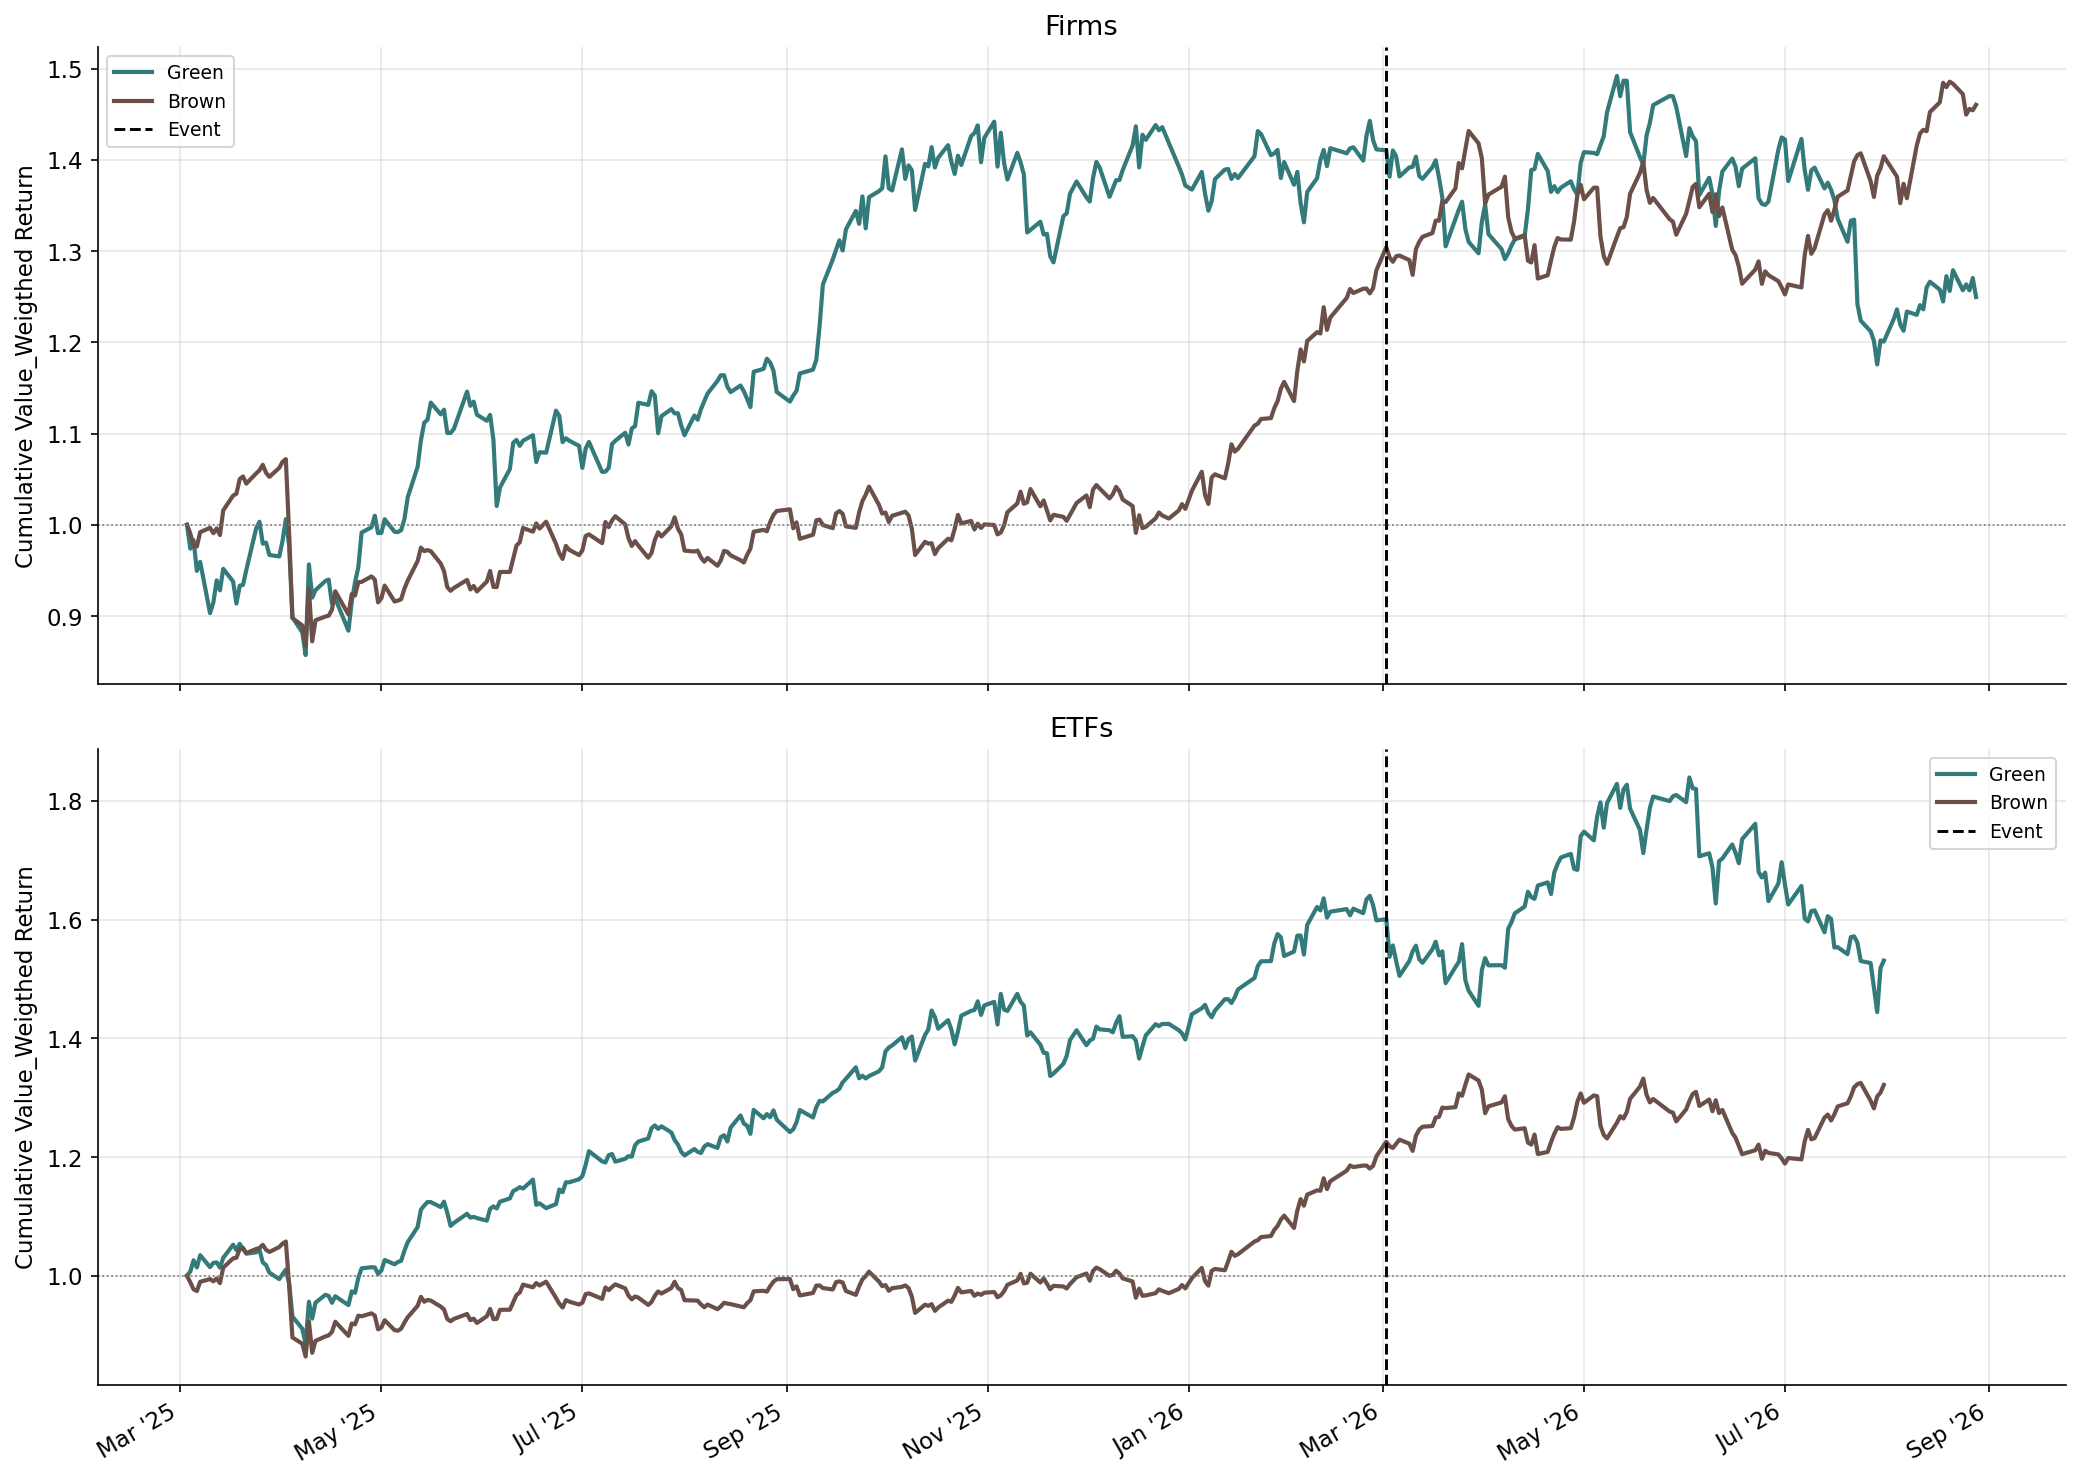

In [27]:
# ── Cumulative returns — last 12 months, value-weighted only ──────────────────
one_year_ago = EVENT_DATE - pd.DateOffset(years=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, (g_p, b_p, title) in zip(axes, [
    (vw_firm_green, vw_firm_brown, "Firms"),
    (vw_etf_green,  vw_etf_brown,  "ETFs"),
]):
    for port, color, lbl in [
        (g_p, GREEN, "Green"),
        (b_p, BROWN, "Brown"),
    ]:
        sub = (port.set_index("date")[vw_ret_col]
                   .loc[one_year_ago:]
                   .dropna())
        cum = (1 + sub).cumprod()
        cum = cum / cum.iloc[0]
        ax.plot(cum.index, cum.values, color=color, lw=2, label=lbl)

    ax.axvline(EVENT_DATE, color="black", lw=1.4, ls="--", label="Event")
    ax.axhline(1, color=GREY, lw=0.8, ls=":")
    ax.set_title(title)
    ax.set_ylabel("Cumulative Value_Weigthed Return")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIG_DIR / "01b_cumulative_vw_1yr.png", dpi=150, bbox_inches="tight")
plt.show()

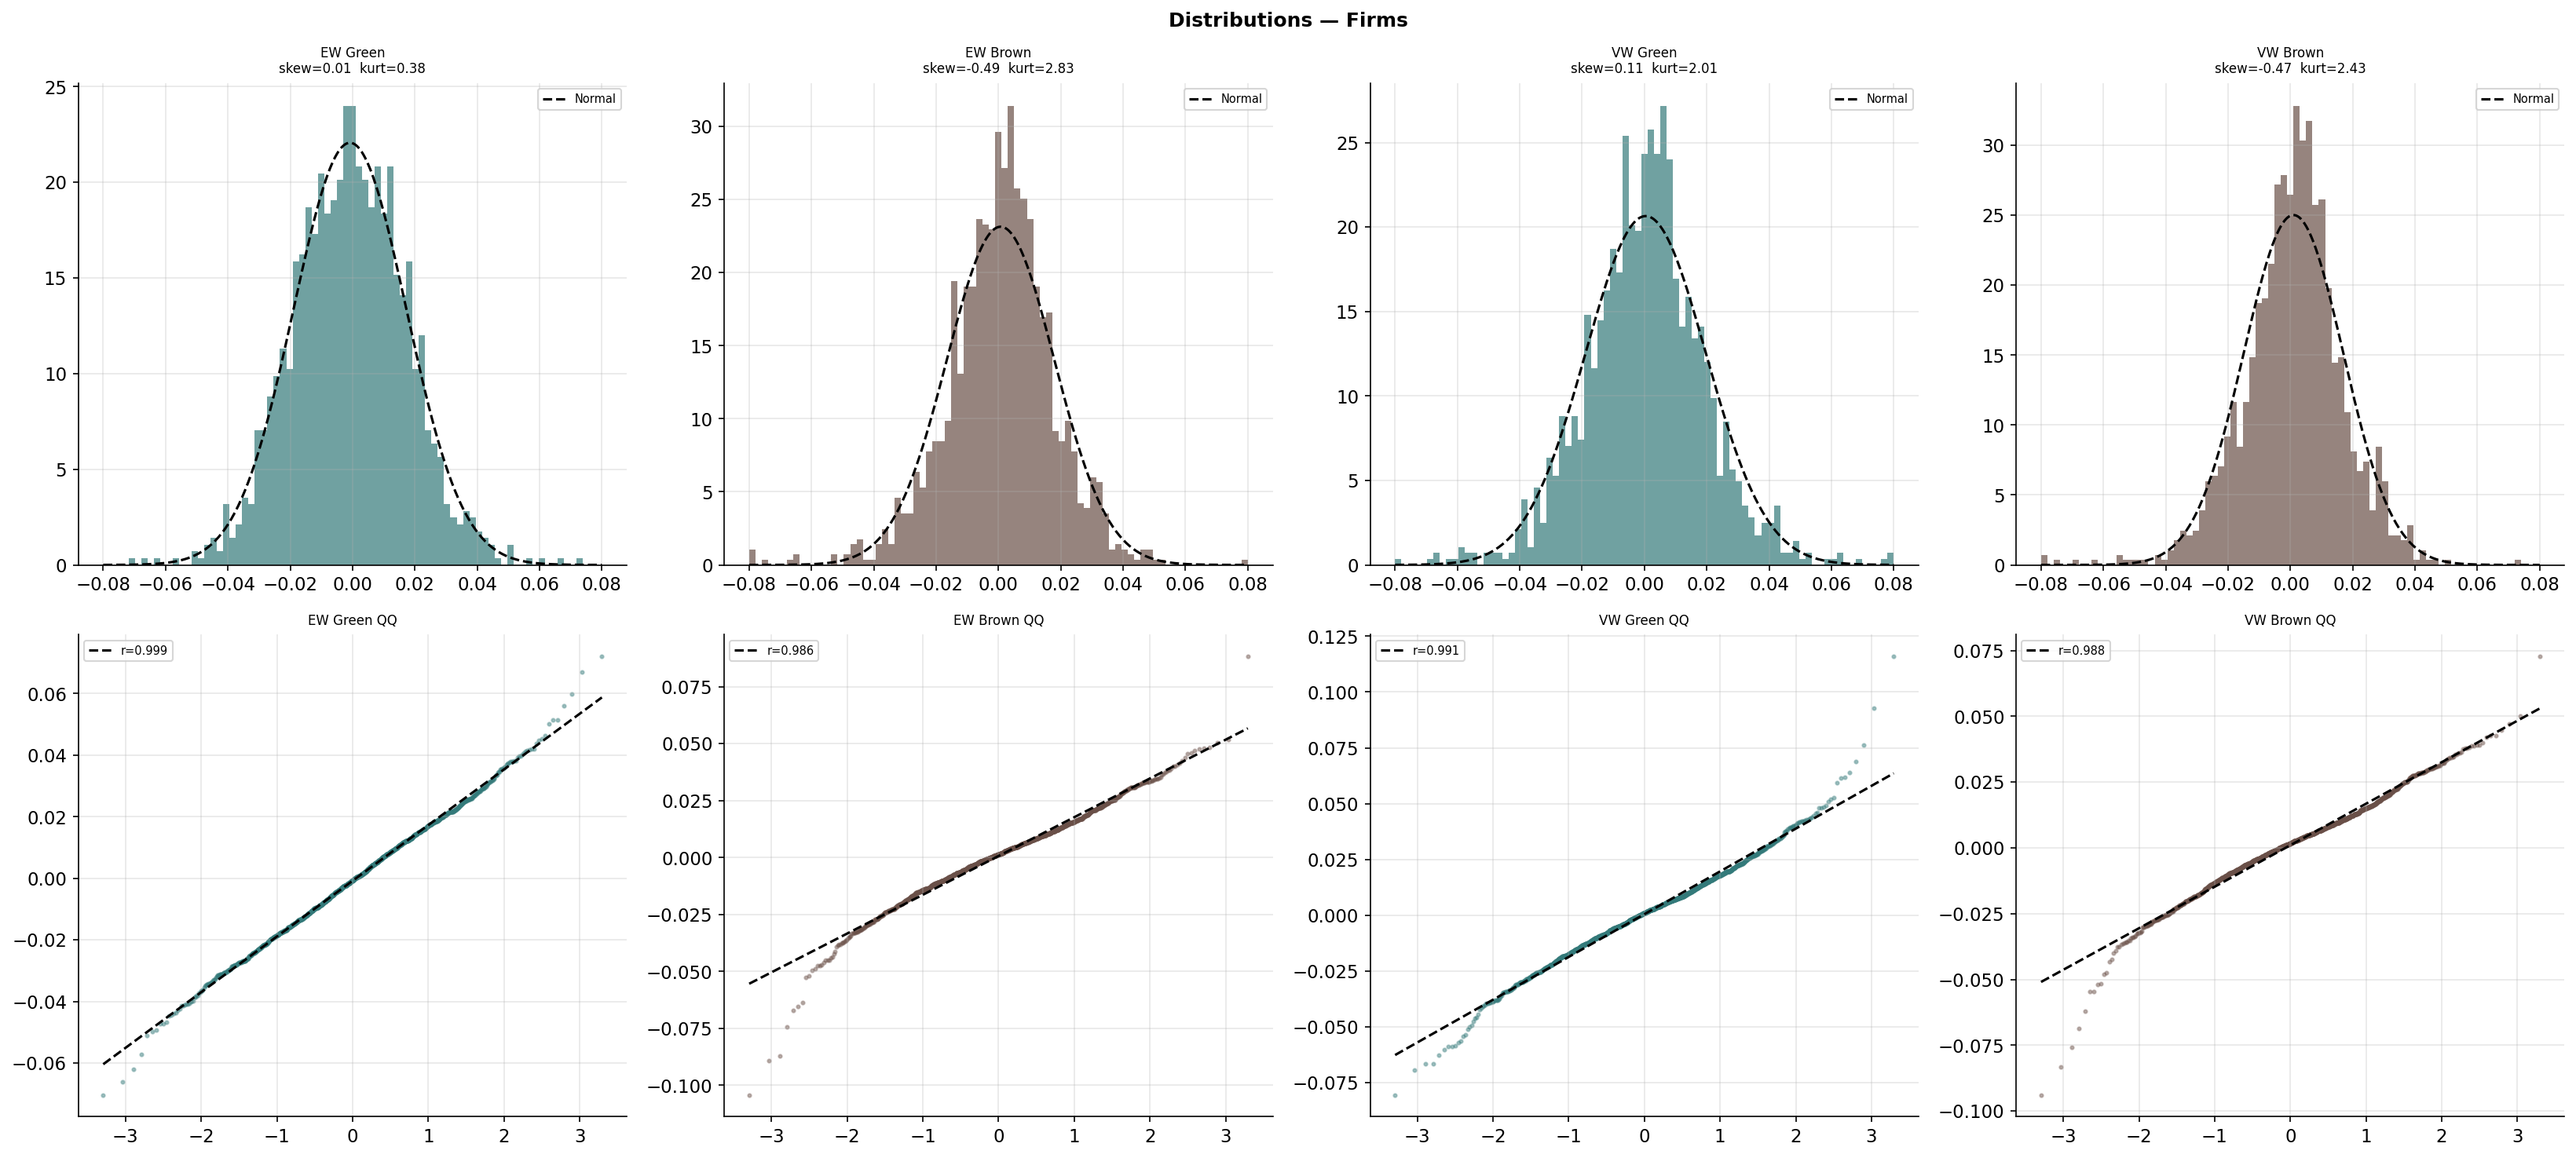

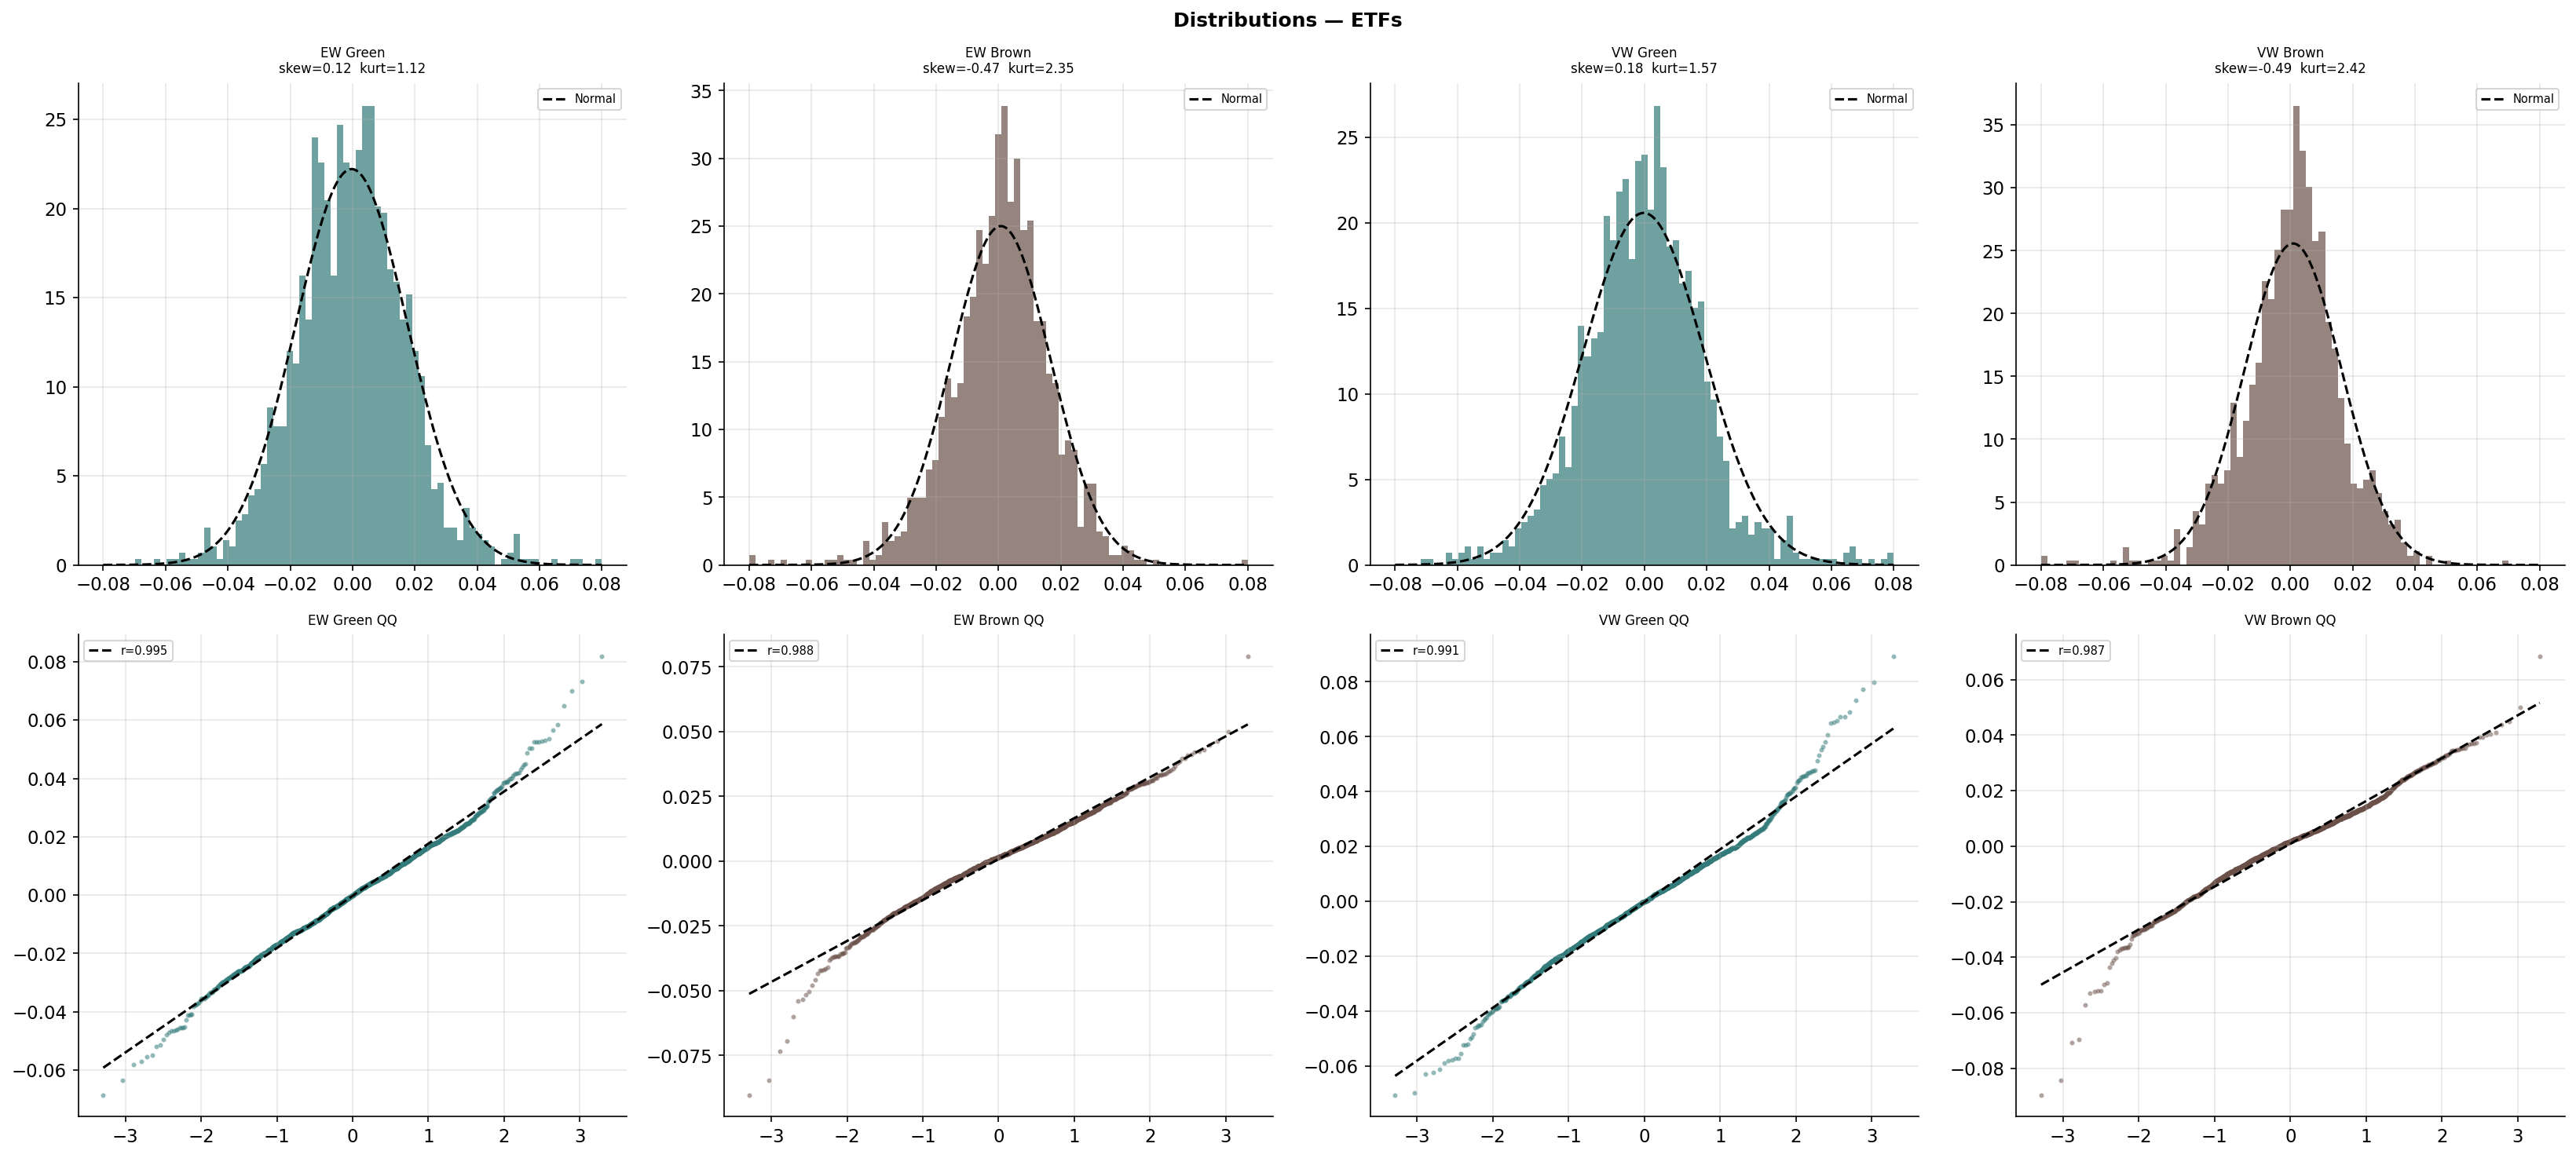


=== Normality Tests ===
         label    n    skew   kurt   jb_p   sw_p  jb_reject  sw_reject
Firms EW Green 1399  0.0076 0.3802 0.0166 0.0895       True      False
Firms EW Brown 1399 -0.4947 2.8342 0.0000 0.0000       True       True
Firms VW Green 1399  0.1126 2.0088 0.0000 0.0000       True       True
Firms VW Brown 1399 -0.4652 2.4289 0.0000 0.0000       True       True
 ETFs EW Green 1399  0.1218 1.1184 0.0000 0.0000       True       True
 ETFs EW Brown 1399 -0.4712 2.3479 0.0000 0.0000       True       True
 ETFs VW Green 1379  0.1788 1.5740 0.0000 0.0000       True       True
 ETFs VW Brown 1379 -0.4903 2.4215 0.0000 0.0000       True       True


In [29]:
CLIP = 0.08
norm_rows = []

for group_label, port_list in [
    ("Firms", [(ew_firm_green,ew_ret_col,"EW Green",GREEN),
               (ew_firm_brown,ew_ret_col,"EW Brown",BROWN),
               (vw_firm_green,vw_ret_col,"VW Green",GREEN),
               (vw_firm_brown,vw_ret_col,"VW Brown",BROWN)]),
    ("ETFs",  [(ew_etf_green, ew_ret_col,"EW Green",GREEN),
               (ew_etf_brown, ew_ret_col,"EW Brown",BROWN),
               (vw_etf_green, vw_ret_col,"VW Green",GREEN),
               (vw_etf_brown, vw_ret_col,"VW Brown",BROWN)]),
]:
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    bins   = np.linspace(-CLIP, CLIP, 80)
    x_norm = np.linspace(-CLIP, CLIP, 300)
    for col,(port,rcol,lbl,color) in enumerate(port_list):
        s  = port[rcol].dropna()
        mu, sigma = s.mean(), s.std()
        jb_stat, jb_p = jarque_bera(s)
        sw_stat, sw_p = shapiro(s.sample(min(len(s),5000),random_state=42))
        _, dag_p = normaltest(s)
        norm_rows.append({
            "label": f"{group_label} {lbl}", "n": len(s),
            "skew": round(s.skew(),4), "kurt": round(s.kurt(),4),
            "jb_p": round(jb_p,4), "sw_p": round(sw_p,4),
            "jb_reject": jb_p<0.05, "sw_reject": sw_p<0.05,
        })
        ax_h=axes[0][col]; ax_q=axes[1][col]
        ax_h.hist(s.clip(-CLIP,CLIP),bins=bins,color=color,alpha=0.7,density=True)
        ax_h.plot(x_norm,stats.norm.pdf(x_norm,mu,sigma),
                  color="black",lw=1.5,ls="--",label="Normal")
        ax_h.set_title(f"{lbl}\nskew={s.skew():.2f}  kurt={s.kurt():.2f}",
                       fontsize=8)
        ax_h.legend(fontsize=7)
        (osm,osr),(sl,ic,r) = stats.probplot(s,dist="norm")
        ax_q.scatter(osm,osr,s=4,alpha=0.4,color=color)
        ax_q.plot(osm,sl*np.array(osm)+ic,color="black",lw=1.5,ls="--",
                  label=f"r={r:.3f}")
        ax_q.set_title(f"{lbl} QQ",fontsize=8); ax_q.legend(fontsize=7)
    plt.suptitle(f"Distributions — {group_label}",
                 fontsize=12,fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR/f"dist_{group_label.lower()}.png",
                dpi=150,bbox_inches="tight")
    plt.show()

print("\n=== Normality Tests ===")
print(pd.DataFrame(norm_rows).to_string(index=False))

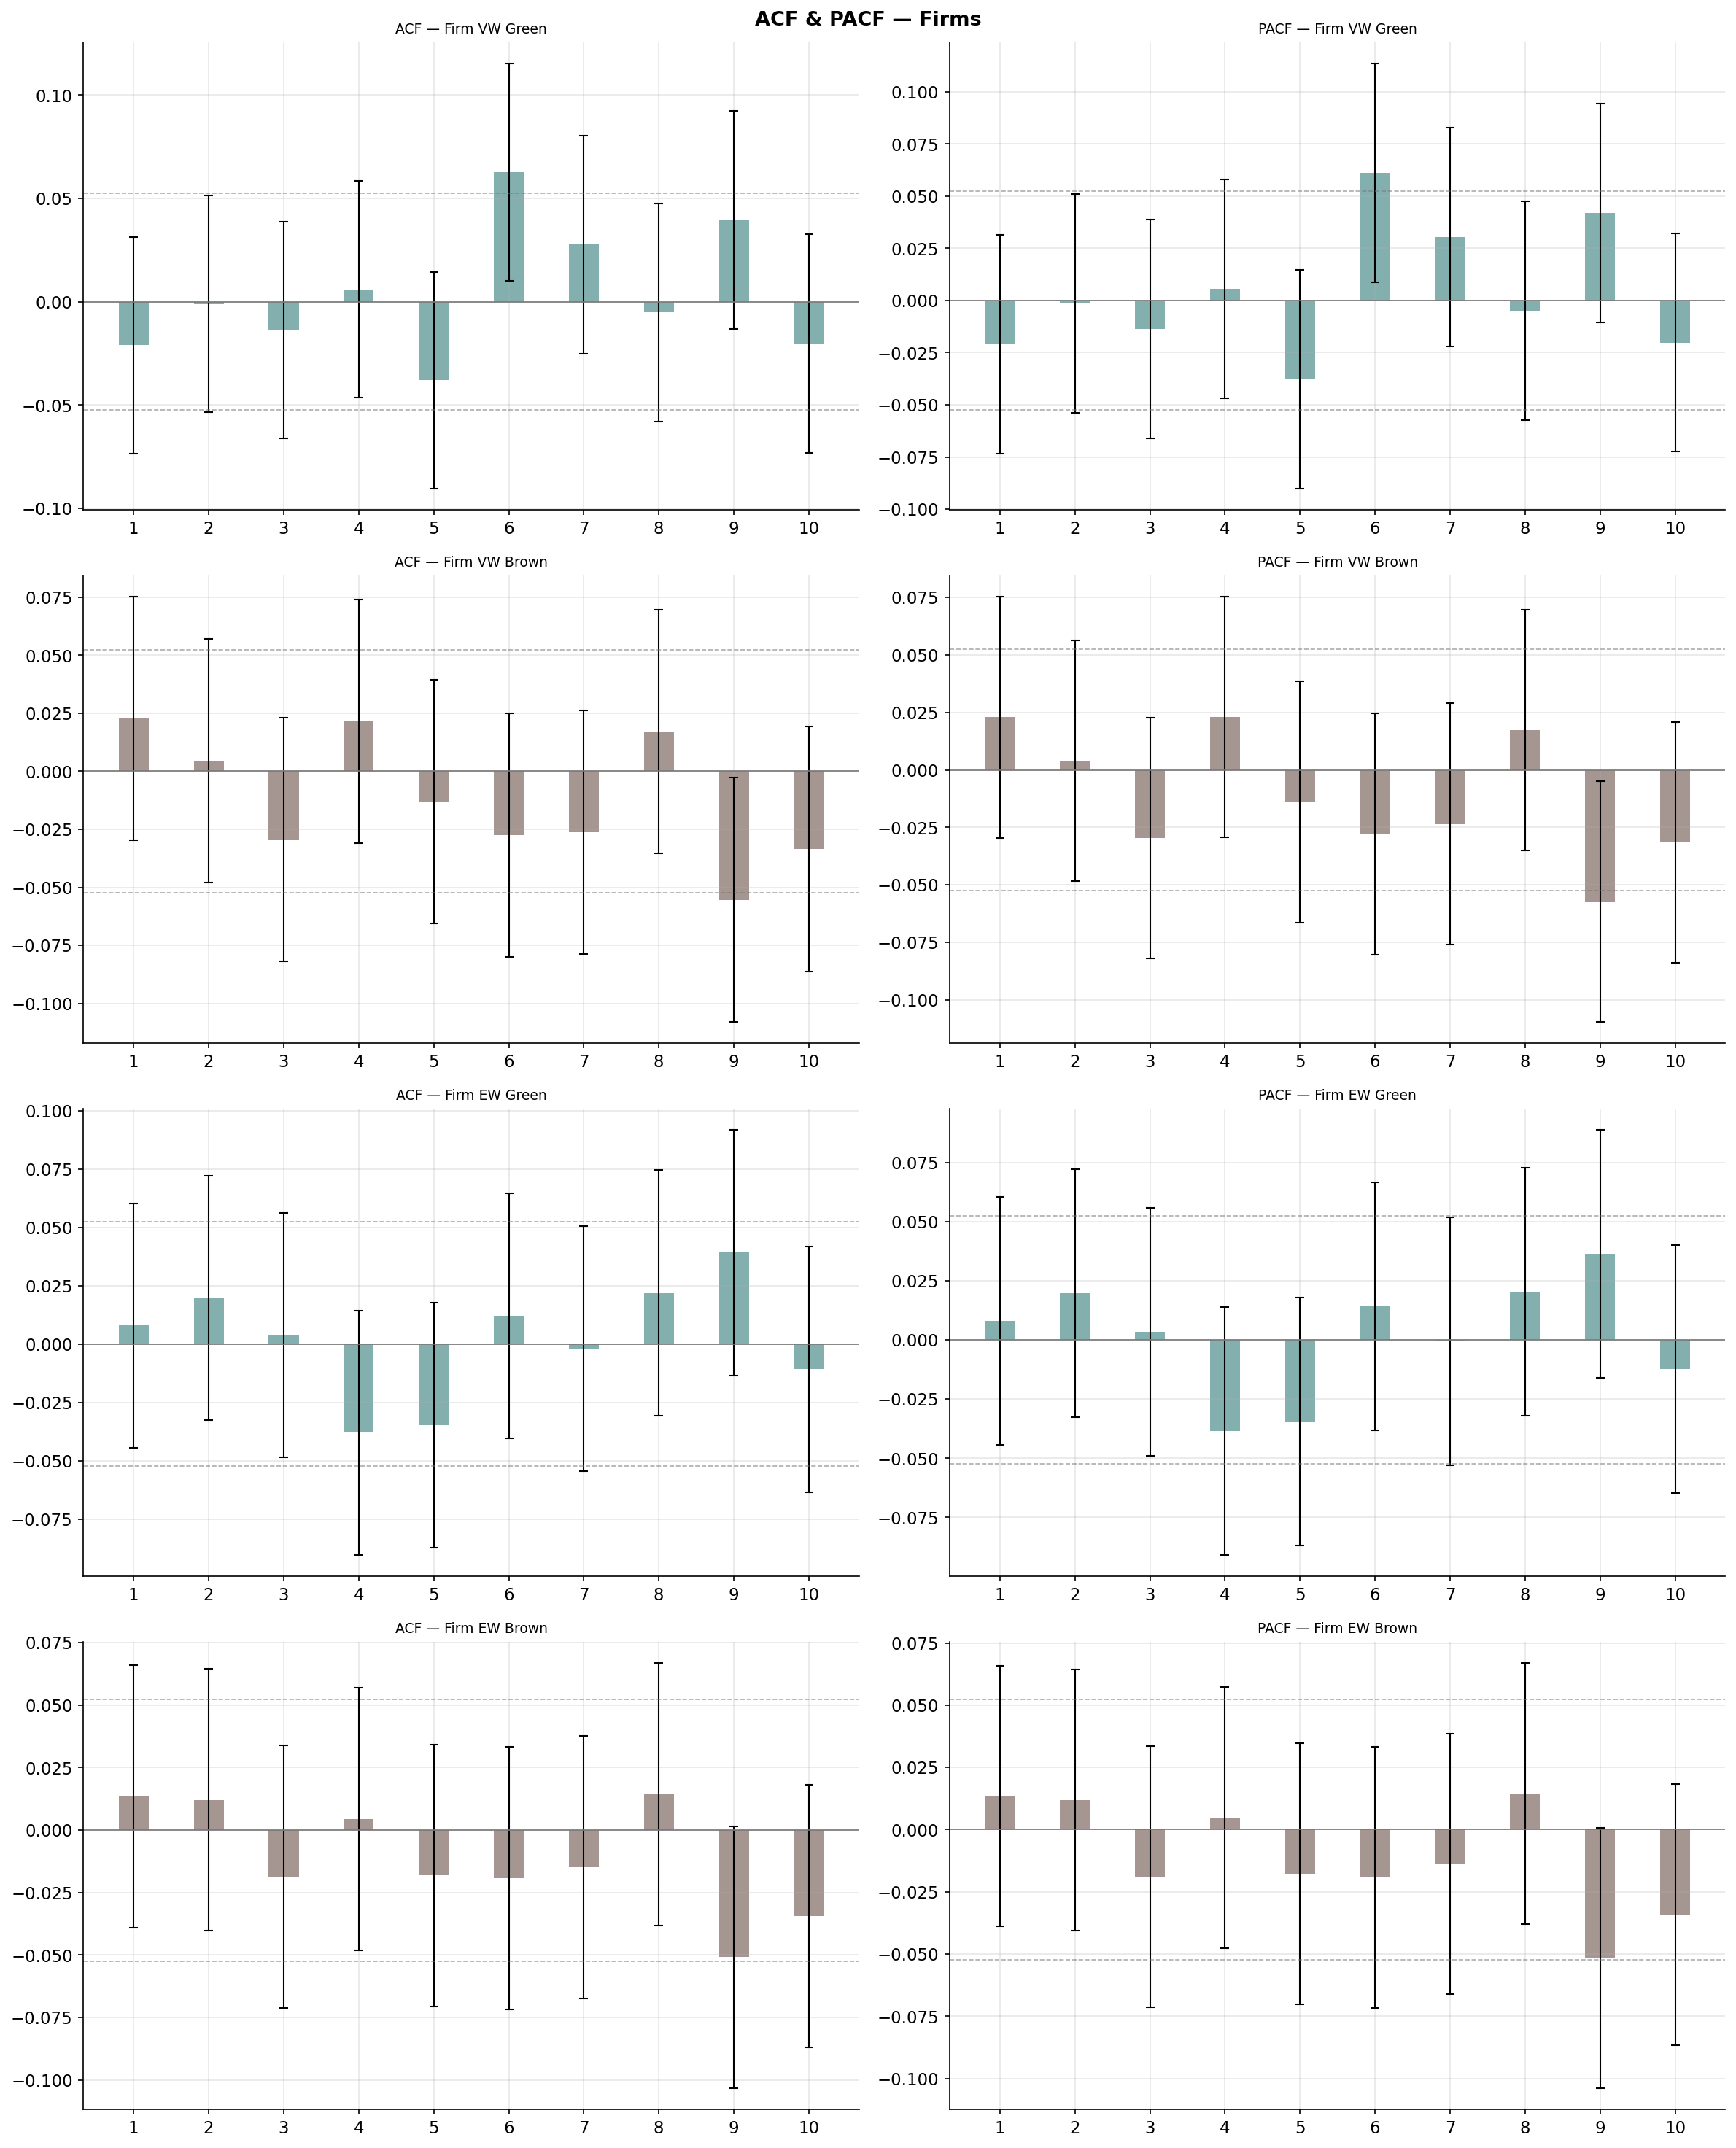

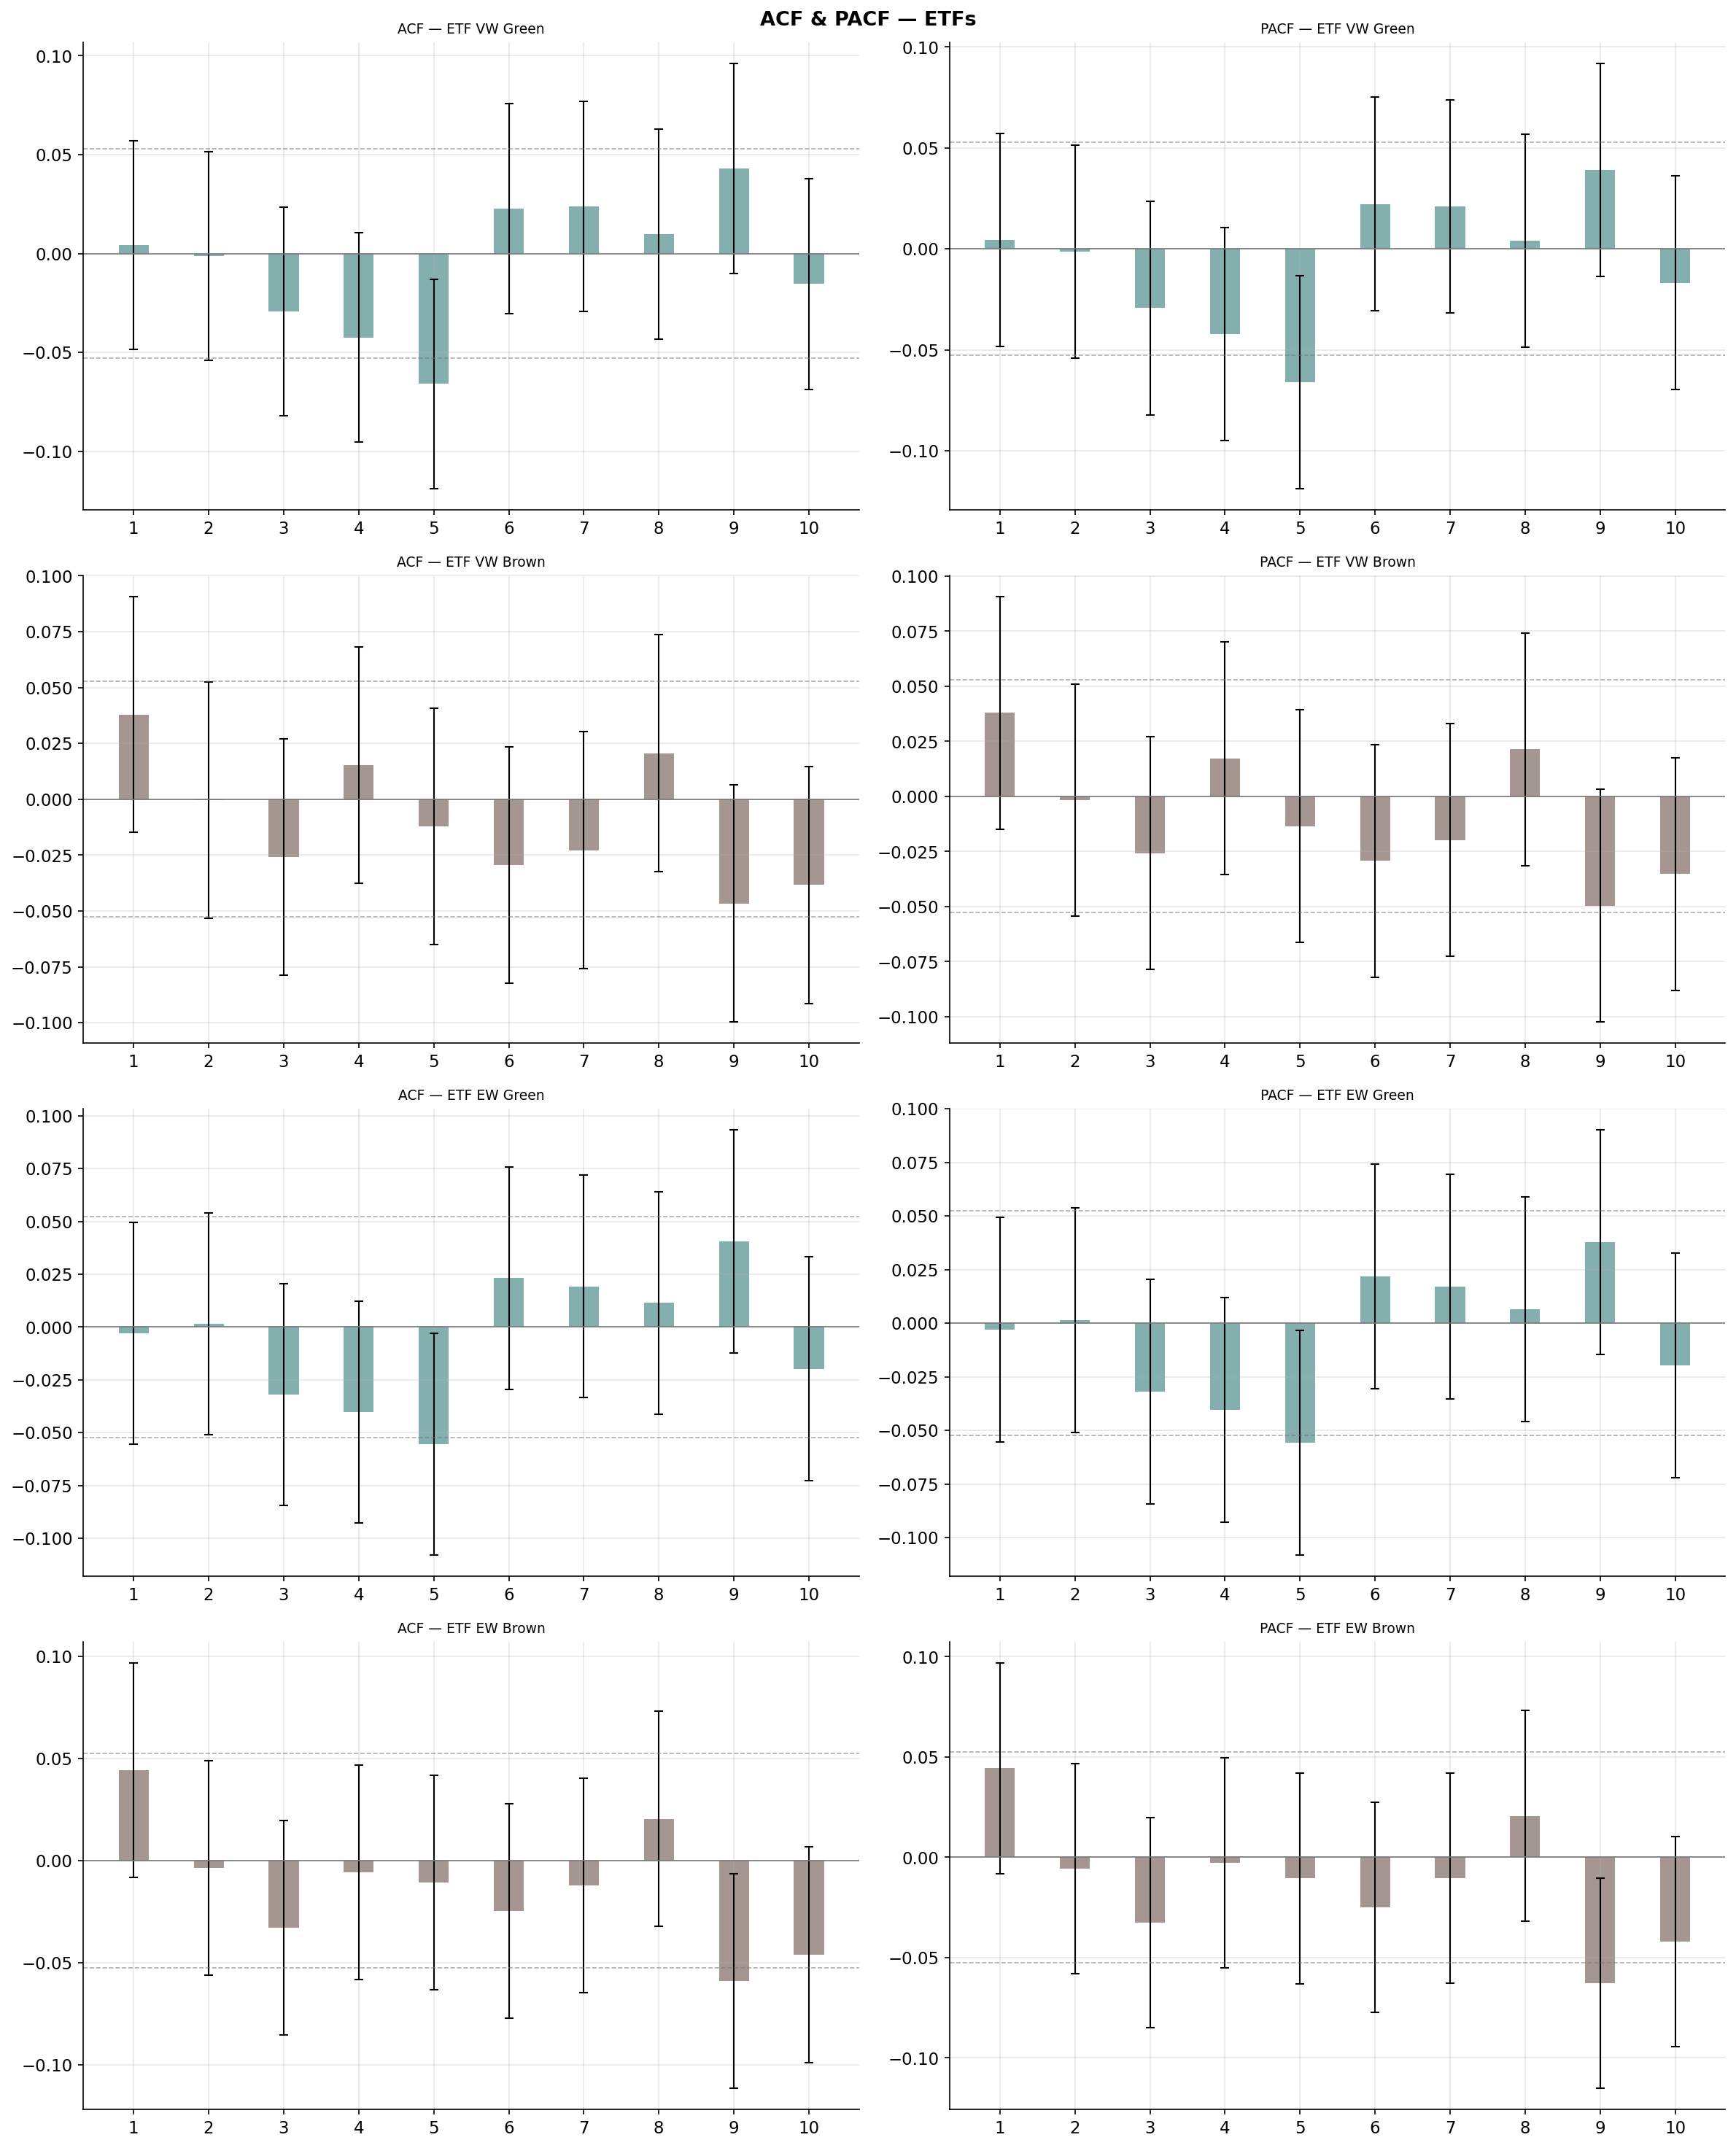

In [30]:
NLAGS = 10
for port_list, fname, title in [
    ([(vw_firm_green,vw_ret_col,"Firm VW Green",GREEN),
      (vw_firm_brown,vw_ret_col,"Firm VW Brown",BROWN),
      (ew_firm_green,ew_ret_col,"Firm EW Green",GREEN),
      (ew_firm_brown,ew_ret_col,"Firm EW Brown",BROWN)],
     "acf_firm.png","Firms"),
    ([(vw_etf_green,vw_ret_col,"ETF VW Green",GREEN),
      (vw_etf_brown,vw_ret_col,"ETF VW Brown",BROWN),
      (ew_etf_green,ew_ret_col,"ETF EW Green",GREEN),
      (ew_etf_brown,ew_ret_col,"ETF EW Brown",BROWN)],
     "acf_etfs.png","ETFs"),
]:
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    for ri,(port,rcol,lbl,color) in enumerate(port_list):
        s    = port[rcol].dropna()
        lags = np.arange(1,NLAGS+1)
        acf_v, acf_ci   = acf(s, nlags=NLAGS, alpha=0.05, fft=True)
        pacf_v, pacf_ci = pacf(s, nlags=NLAGS, alpha=0.05, method="ywm")
        for ci2,(vals,ci,kind) in enumerate([
            (acf_v[1:], acf_ci[1:], "ACF"),
            (pacf_v[1:],pacf_ci[1:],"PACF"),
        ]):
            ax = axes[ri][ci2]
            lo = ci[:,0]-vals; hi = ci[:,1]-vals
            ax.bar(lags,vals,color=color,alpha=0.6,width=0.4)
            ax.errorbar(lags,vals,yerr=[-lo,hi],
                        fmt="none",color="black",capsize=3,lw=1)
            ax.axhline(0,                      color=GREY,lw=0.8)
            ax.axhline( 1.96/np.sqrt(len(s)), color=GREY,lw=0.8,ls="--",alpha=0.6)
            ax.axhline(-1.96/np.sqrt(len(s)), color=GREY,lw=0.8,ls="--",alpha=0.6)
            ax.set_title(f"{kind} — {lbl}",fontsize=9)
            ax.set_xticks(lags)
    plt.suptitle(f"ACF & PACF — {title}",
                 fontsize=13,fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR/fname,dpi=150,bbox_inches="tight")
    plt.show()

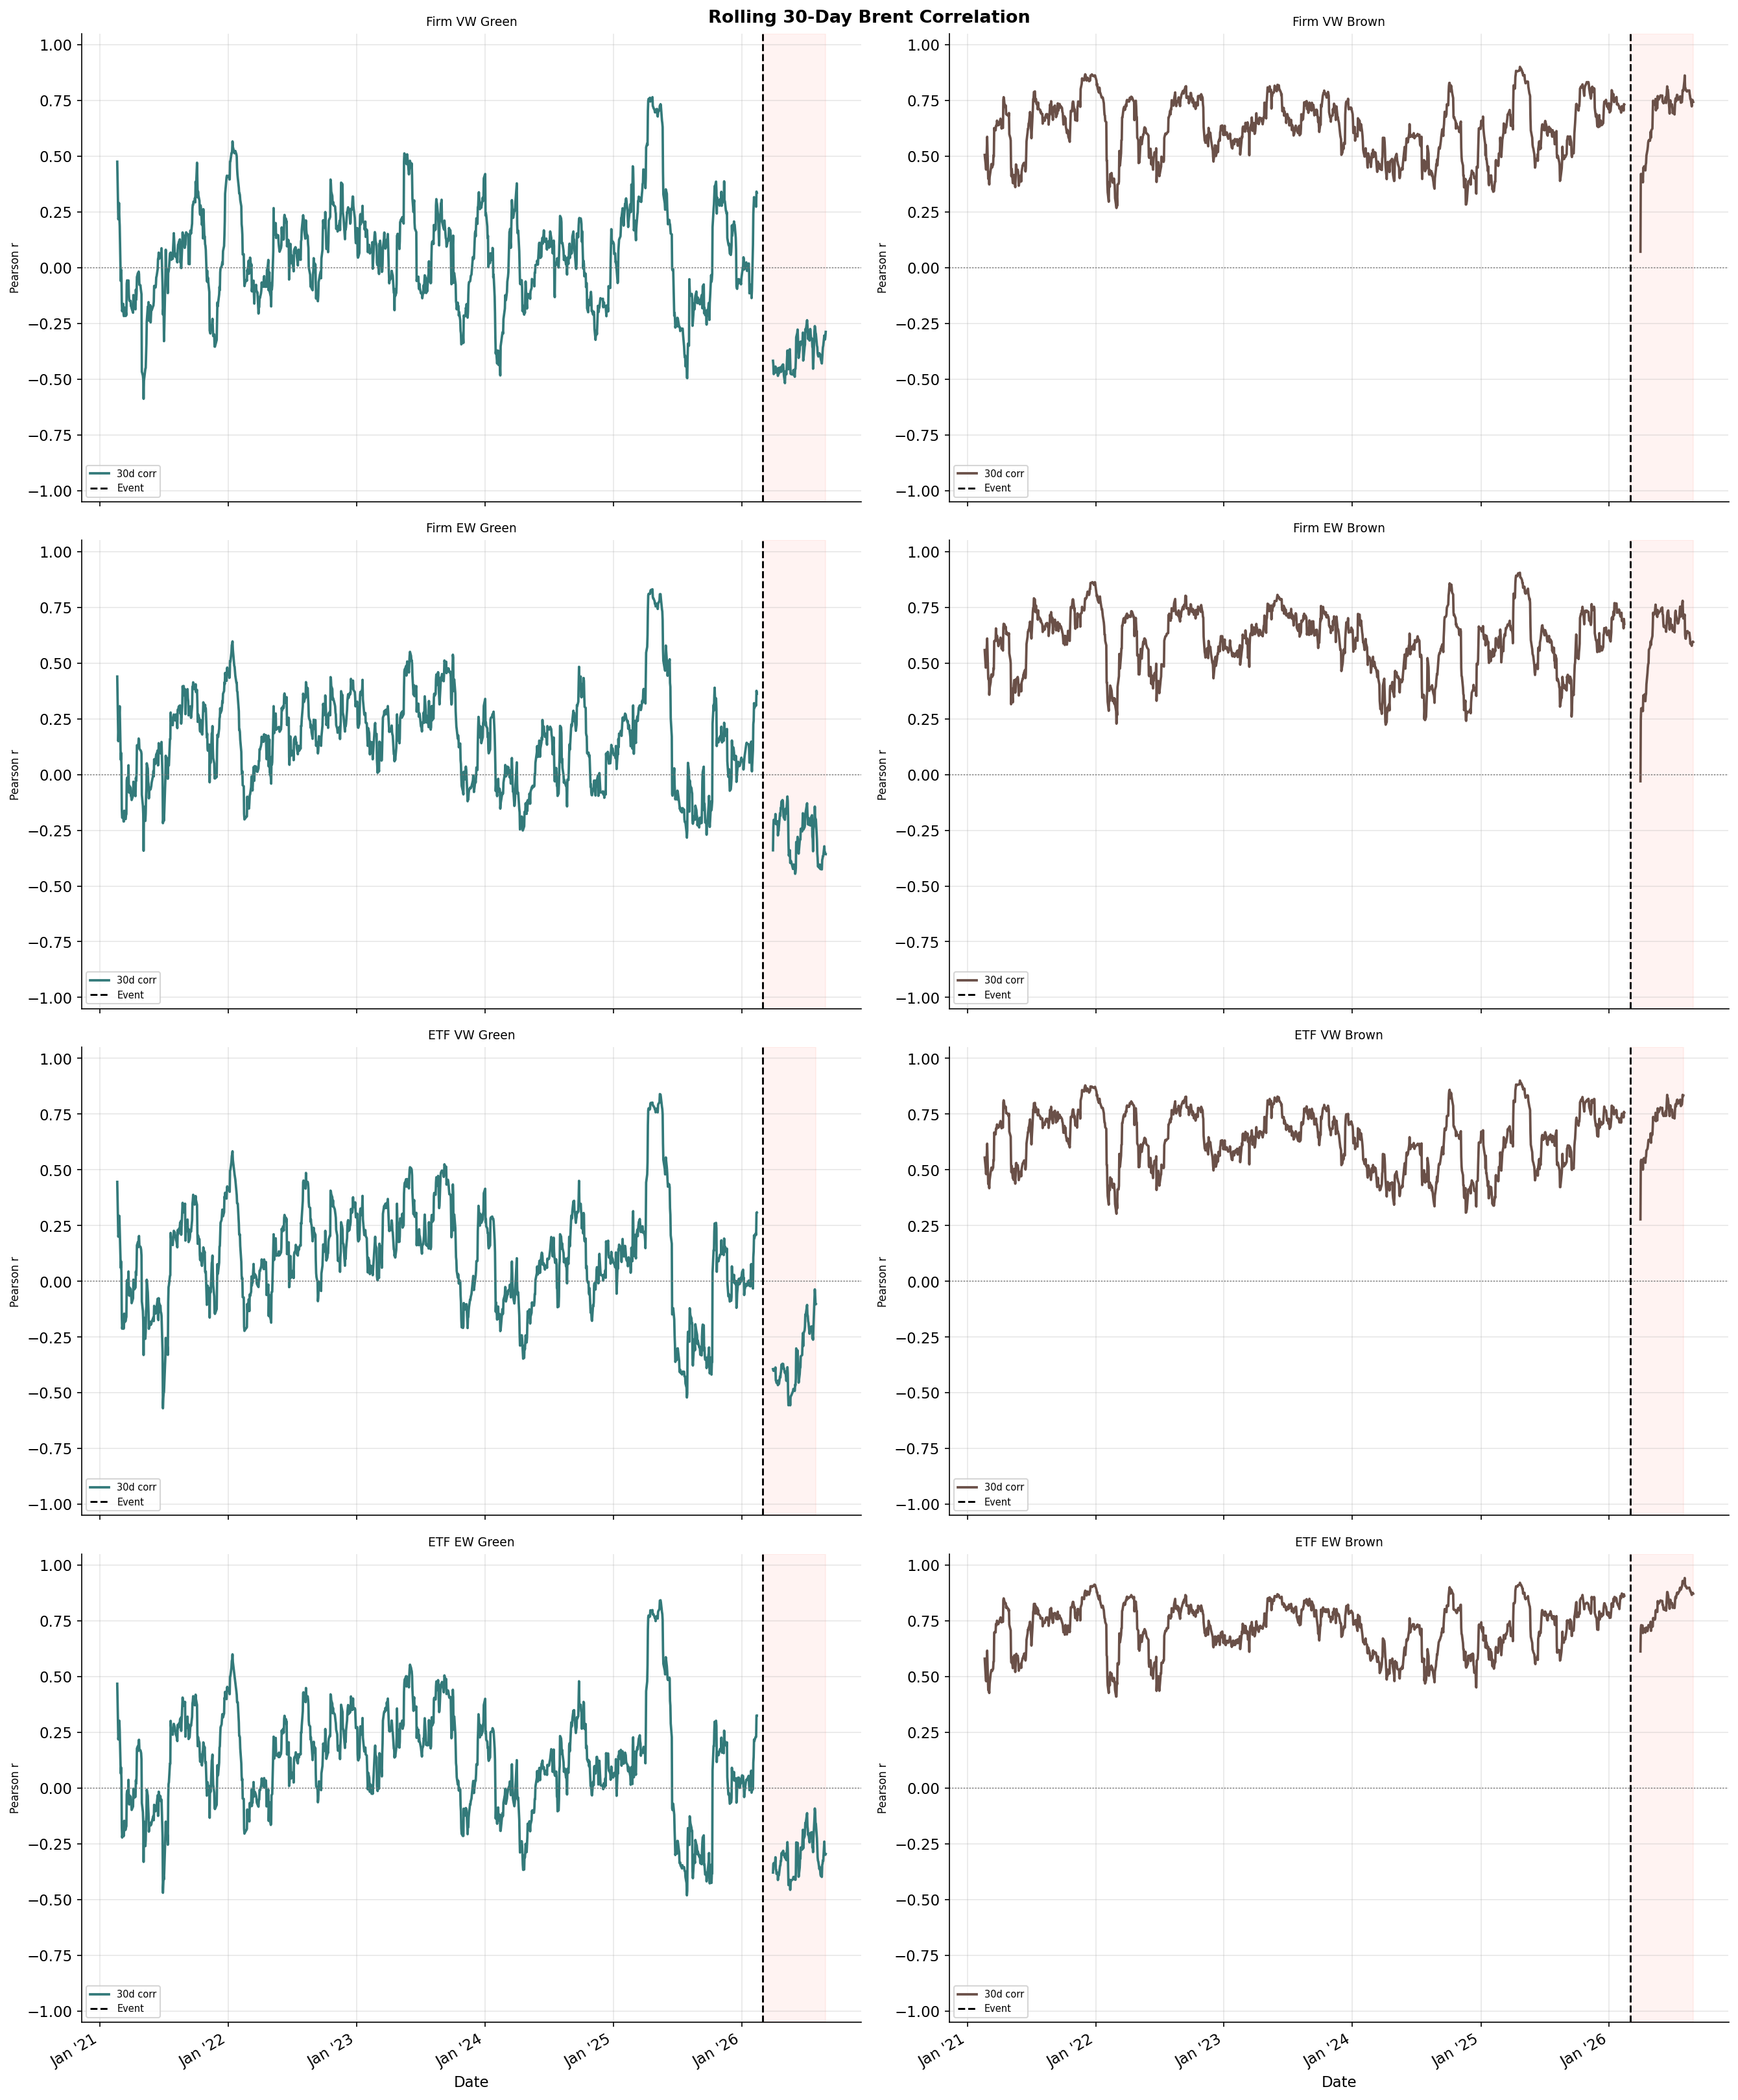

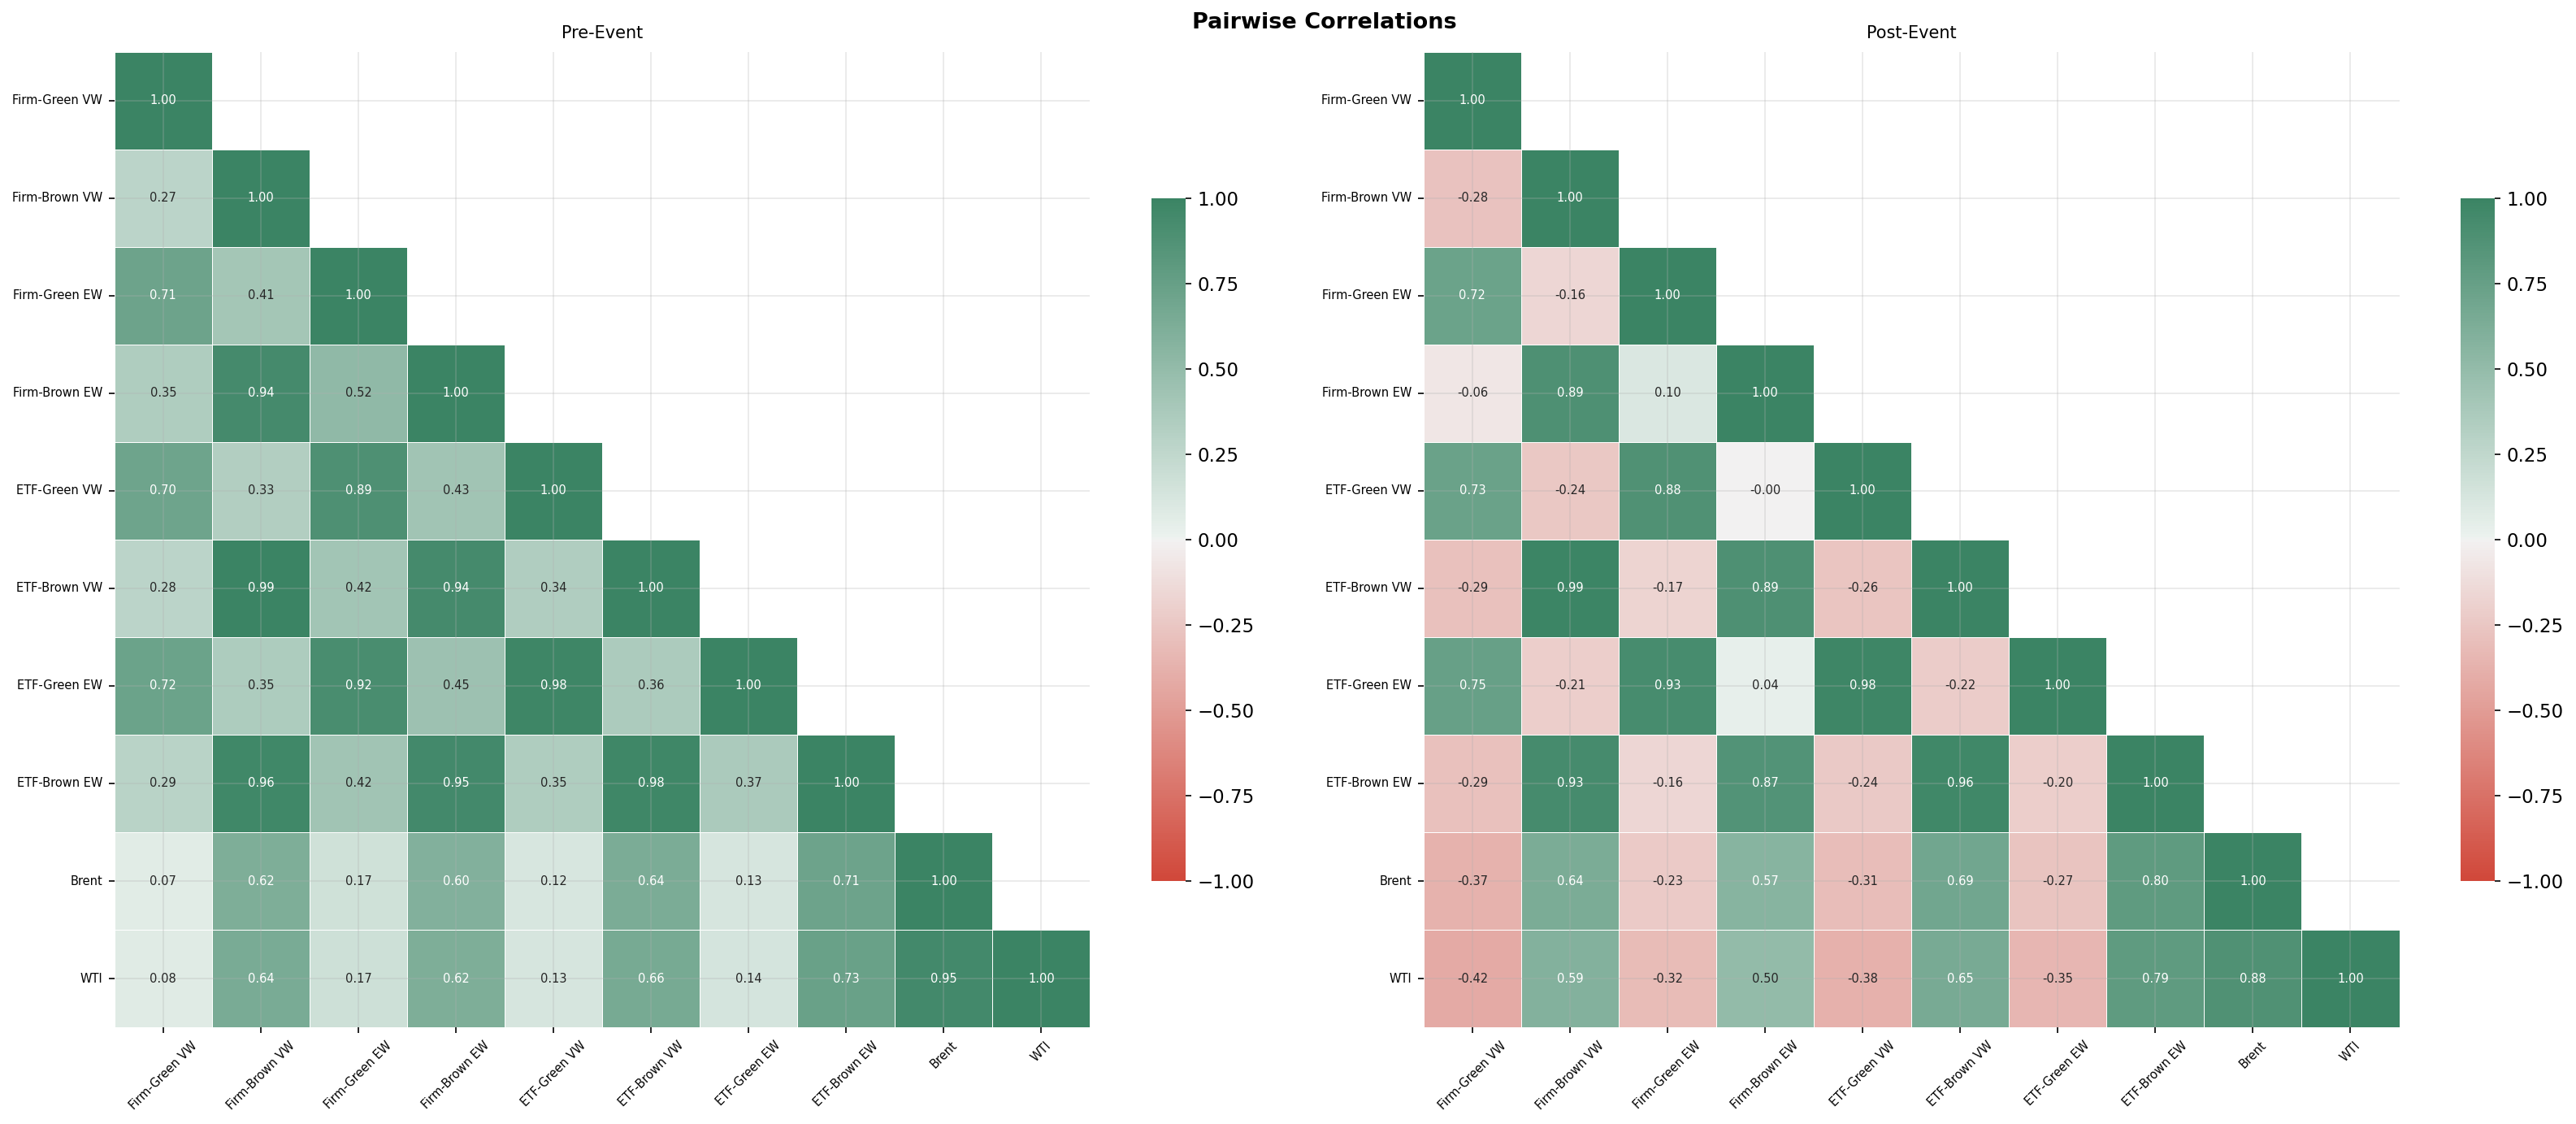

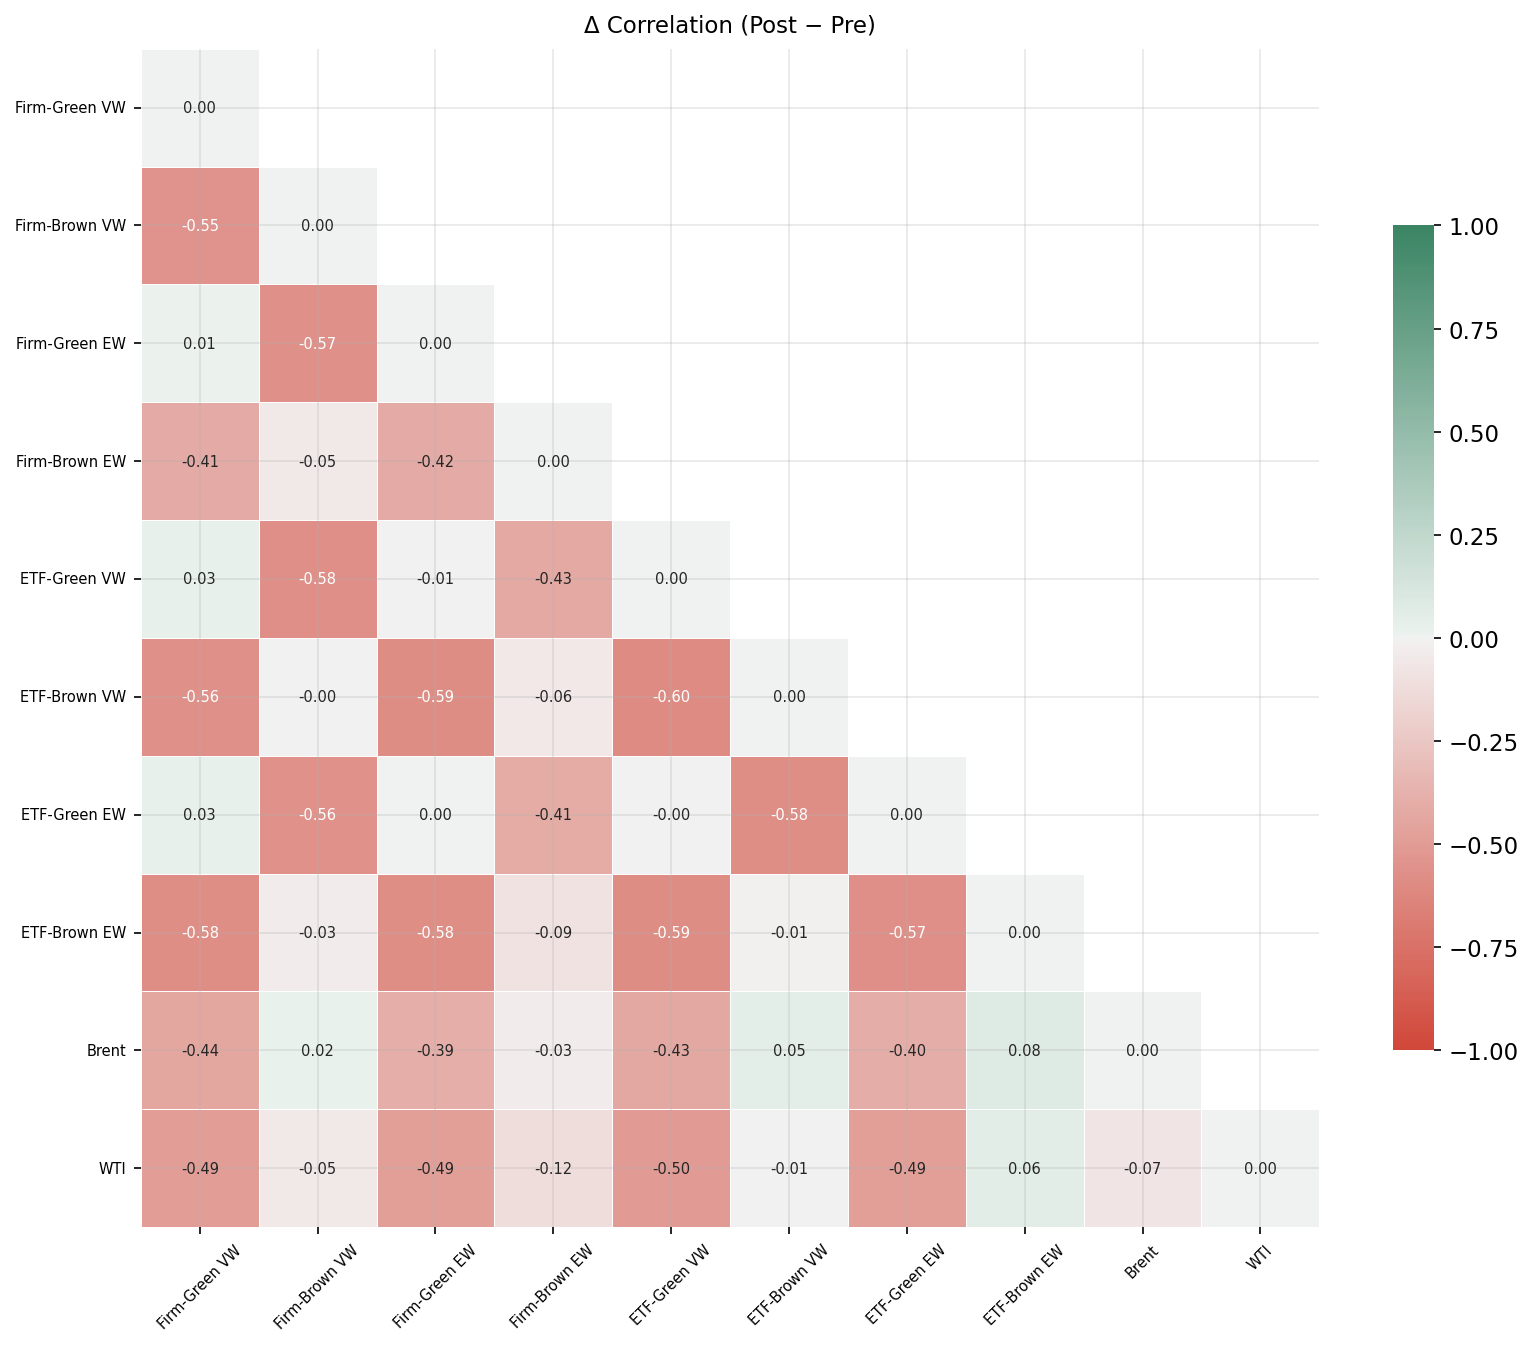

In [38]:
WINDOW    = 30
daily_ref = firm_panel.drop_duplicates("date").set_index("date").sort_index()
brent_ret = daily_ref["brent_log_return"]

combos_oil = [
    (vw_firm_green,vw_ret_col,"Firm VW Green",GREEN),
    (vw_firm_brown,vw_ret_col,"Firm VW Brown",BROWN),
    (ew_firm_green,ew_ret_col,"Firm EW Green",GREEN),
    (ew_firm_brown,ew_ret_col,"Firm EW Brown",BROWN),
    (vw_etf_green, vw_ret_col,"ETF VW Green", GREEN),
    (vw_etf_brown, vw_ret_col,"ETF VW Brown", BROWN),
    (ew_etf_green, ew_ret_col,"ETF EW Green", GREEN),
    (ew_etf_brown, ew_ret_col,"ETF EW Brown", BROWN),
]

fig, axes = plt.subplots(4, 2, figsize=(18, 22), sharex=True)
for idx,(port,rcol,lbl,color) in enumerate(combos_oil):
    ax = axes[idx//2][idx%2]
    ps = port.set_index("date")[rcol]
    rc = ps.rolling(WINDOW).corr(brent_ret)
    ax.plot(rc.index, rc.values, color=color, lw=1.8, label=f"{WINDOW}d corr")
    ax.axhline(0,          color=GREY,  lw=0.8, ls=":")
    ax.axvline(EVENT_DATE, color="black",lw=1.4, ls="--", label="Event")
    ax.axvspan(EVENT_DATE, ps.index.max(), alpha=0.07, color="tomato", zorder=0)
    ax.set_title(lbl, fontsize=9); ax.set_ylabel("Pearson r", fontsize=8)
    ax.set_ylim(-1.05, 1.05); ax.legend(fontsize=7, loc="lower left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[-1][0].set_xlabel("Date"); axes[-1][1].set_xlabel("Date")
fig.autofmt_xdate()
plt.suptitle(f"Rolling {WINDOW}-Day Brent Correlation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR/"brent_corr_clean.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation heatmaps
corr_data = pd.DataFrame({
    "Firm-Green VW": vw_firm_green.set_index("date")[vw_ret_col],
    "Firm-Brown VW": vw_firm_brown.set_index("date")[vw_ret_col],
    "Firm-Green EW": ew_firm_green.set_index("date")[ew_ret_col],
    "Firm-Brown EW": ew_firm_brown.set_index("date")[ew_ret_col],
    "ETF-Green VW":  vw_etf_green.set_index("date")[vw_ret_col],
    "ETF-Brown VW":  vw_etf_brown.set_index("date")[vw_ret_col],
    "ETF-Green EW":  ew_etf_green.set_index("date")[ew_ret_col],
    "ETF-Brown EW":  ew_etf_brown.set_index("date")[ew_ret_col],
}).join(daily_ref[["brent_log_return","wti_log_return"]],
        how="left"
).rename(columns={"brent_log_return":"Brent","wti_log_return":"WTI"}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, mask, title in [
    (axes[0], corr_data.index <  EVENT_DATE, "Pre-Event"),
    (axes[1], corr_data.index >= EVENT_DATE, "Post-Event"),
]:
    corr = corr_data[mask].corr()
    m    = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=m, annot=True, fmt=".2f",
                cmap=sns.diverging_palette(15,150,as_cmap=True),
                vmin=-1, vmax=1, ax=ax, linewidths=0.4, linecolor="white",
                annot_kws={"size":7}, cbar_kws={"shrink":0.7}, square=True)
    ax.set_title(title, fontsize=10, pad=8)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.suptitle("Pairwise Correlations",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR/"heatmap_clean.png", dpi=150, bbox_inches="tight")
plt.show()

delta = (corr_data[corr_data.index >= EVENT_DATE].corr()
         - corr_data[corr_data.index <  EVENT_DATE].corr())
fig, ax = plt.subplots(figsize=(11, 9))
m = np.triu(np.ones_like(delta, dtype=bool), k=1)
sns.heatmap(delta, mask=m, annot=True, fmt=".2f",
            cmap=sns.diverging_palette(15,150,as_cmap=True),
            vmin=-1, vmax=1, ax=ax, linewidths=0.4, linecolor="white",
            annot_kws={"size":7}, cbar_kws={"shrink":0.7}, square=True)
ax.set_title("Δ Correlation (Post − Pre)", fontsize=11, pad=8)
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR/"heatmap_delta.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
import statsmodels.api as sm
from scipy import stats
from scipy.stats import bartlett, levene

# ── Build pre-event daily returns for both groups ─────────────────────────────
pre_g = (vw_firm_green.set_index("date")[vw_ret_col]
                      .loc[:EVENT_DATE - pd.Timedelta(days=1)]
                      .dropna()
                      .rename("return"))
pre_b = (vw_firm_brown.set_index("date")[vw_ret_col]
                      .loc[:EVENT_DATE - pd.Timedelta(days=1)]
                      .dropna()
                      .rename("return"))

print(f"Pre-event window: {pre_g.index.min().date()} → {pre_g.index.max().date()}")
print(f"  Green obs: {len(pre_g)}  Brown obs: {len(pre_b)}")


Pre-event window: 2021-01-05 → 2026-02-27
  Green obs: 1274  Brown obs: 1274


In [33]:

# ──────────────────────────────────────────────────────────────────────────────
# Test 1: Equality of pre-event means (Welch t-test)
# H0: mean return is equal for green and brown pre-event
# ──────────────────────────────────────────────────────────────────────────────
t_stat, p_val = stats.ttest_ind(pre_g, pre_b, equal_var=False)
print(f"\n{'━'*60}")
print(f"Test 1 — Welch t-test: equal pre-event means")
print(f"  Green mean : {pre_g.mean()*100:.4f}%")
print(f"  Brown mean : {pre_b.mean()*100:.4f}%")
print(f"  Difference : {(pre_g.mean()-pre_b.mean())*100:.4f}%")
print(f"  t-stat     : {t_stat:.4f}")
print(f"  p-value    : {p_val:.4f}")
print(f"  Result     : {'No significant difference ' if p_val > 0.05 else 'Significant difference'}")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Test 1 — Welch t-test: equal pre-event means
  Green mean : 0.0527%
  Brown mean : 0.0990%
  Difference : -0.0463%
  t-stat     : -0.6522
  p-value    : 0.5143
  Result     : No significant difference 


In [34]:

# ──────────────────────────────────────────────────────────────────────────────
# Test 2: Equality of pre-event variances (Levene test)
# H0: variance is equal for green and brown pre-event
# ──────────────────────────────────────────────────────────────────────────────
lev_stat, lev_p = levene(pre_g, pre_b)
print(f"\n{'━'*60}")
print(f"Test 2 — Levene test: equal pre-event variances")
print(f"  Green std  : {pre_g.std()*100:.4f}%")
print(f"  Brown std  : {pre_b.std()*100:.4f}%")
print(f"  Levene stat: {lev_stat:.4f}")
print(f"  p-value    : {lev_p:.4f}")
print(f"  Result     : {'No significant difference' if lev_p > 0.05 else ' Significant difference'}")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Test 2 — Levene test: equal pre-event variances
  Green std  : 1.9508%
  Brown std  : 1.6141%
  Levene stat: 32.2011
  p-value    : 0.0000
  Result     :  Significant difference


In [35]:

# ──────────────────────────────────────────────────────────────────────────────
# Test 3: Interaction regression — the core parallel trends test
# Model: return = α + β₁·time + β₂·green + β₃·(time × green) + ε
# H0: β₃ = 0 (no differential time trend between green and brown)
# A significant β₃ means the gap was already moving before the event → 
# parallel trends violated
# ──────────────────────────────────────────────────────────────────────────────
df_reg = pd.concat([
    pre_g.reset_index().assign(green=1),
    pre_b.reset_index().assign(green=0),
], ignore_index=True).sort_values("date")

# Numeric time index (days since start of pre-event window)
t0 = df_reg["date"].min()
df_reg["time"]         = (df_reg["date"] - t0).dt.days
df_reg["time_x_green"] = df_reg["time"] * df_reg["green"]

X = sm.add_constant(df_reg[["time","green","time_x_green"]])
y = df_reg["return"]
model = sm.OLS(y, X).fit(cov_type="HC3")   # heteroskedasticity-robust SEs

print(f"\n{'━'*60}")
print(f"Test 3 — Interaction regression (parallel trends)")
print(f"  Model: return = α + β·time + γ·green + δ·(time×green) + ε")
print(f"  H0: δ = 0  (no differential pre-event trend)")
print()
print(f"  {'Coef':<20} {'Estimate':>12}  {'Std Err':>10}  "
      f"{'t-stat':>8}  {'p-value':>8}")
print("  " + "─"*65)
for pname, coef, se, tstat, pv in zip(
    model.params.index,
    model.params,
    model.bse,
    model.tvalues,
    model.pvalues,
):
    flag = " ← KEY" if pname == "time_x_green" else ""
    print(f"  {pname:<20} {coef*100:>12.6f}  {se*100:>10.6f}  "
          f"{tstat:>8.3f}  {pv:>8.4f}{flag}")

delta_p = model.pvalues["time_x_green"]
print(f"\n  Result: {' δ insignificant — parallel trends supported' if delta_p > 0.05 else ' δ significant — parallel trends may be violated'}"
      f"  (p = {delta_p:.4f})")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Test 3 — Interaction regression (parallel trends)
  Model: return = α + β·time + γ·green + δ·(time×green) + ε
  H0: δ = 0  (no differential pre-event trend)

  Coef                     Estimate     Std Err    t-stat   p-value
  ─────────────────────────────────────────────────────────────────
  const                    0.176774    0.103446     1.709    0.0875
  time                    -0.000083    0.000086    -0.968    0.3333
  green                   -0.205449    0.152984    -1.343    0.1793
  time_x_green             0.000169    0.000133     1.276    0.2021 ← KEY

  Result:  δ insignificant — parallel trends supported  (p = 0.2021)


In [36]:

# ──────────────────────────────────────────────────────────────────────────────
# Test 4: Placebo test — is the green−brown spread significant on fake event dates?
# Pick 20 random dates in the pre-event window and test the spread at each
# If parallel trends hold, none should be significant
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n{'━'*60}")
print(f"Test 4 — Placebo dates (20 random pre-event dates)")
print(f"  H0: green−brown spread = 0 at each fake event date")
print(f"  {'Placebo date':<15} {'Spread %':>10}  {'t-stat':>8}  "
      f"{'p-value':>9}  {'Sig':>5}")
print("  " + "─"*55)

pre_dates = pd.bdate_range(pre_g.index.min(), pre_g.index.max())
np.random.seed(42)
placebo_dates = np.random.choice(pre_dates[20:-20], size=20, replace=False)
placebo_dates = sorted(placebo_dates)

n_sig = 0
for pd_date in placebo_dates:
    # Post-placebo window: 30 days after fake event
    post_g = (vw_firm_green.set_index("date")[vw_ret_col]
                           .loc[pd_date: pd_date + pd.Timedelta(days=30)]
                           .dropna())
    post_b = (vw_firm_brown.set_index("date")[vw_ret_col]
                           .loc[pd_date: pd_date + pd.Timedelta(days=30)]
                           .dropna())
    if len(post_g) < 5 or len(post_b) < 5:
        continue
    t, p = stats.ttest_ind(post_g, post_b, equal_var=False)
    spread = (post_g.mean() - post_b.mean()) * 100
    sig    = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""
    if sig: n_sig += 1
    print(f"  {str(pd.Timestamp(pd_date).date()):<15} "
          f"{spread:>10.4f}  {t:>8.3f}  {p:>9.4f}  {sig:>5}")

print(f"\n  Significant at 10%: {n_sig}/20 placebo dates")
print(f"  Result: {' Low false-positive rate — parallel trends supported' if n_sig <= 3 else ' High false-positive rate — investigate pre-trends'}")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Test 4 — Placebo dates (20 random pre-event dates)
  H0: green−brown spread = 0 at each fake event date
  Placebo date      Spread %    t-stat    p-value    Sig
  ───────────────────────────────────────────────────────
  2021-04-14         -0.9626    -2.006     0.0511      *
  2021-05-04         -0.7378    -1.514     0.1382       
  2022-01-04         -1.6882    -2.496     0.0177     **
  2022-06-22          0.6280     0.981     0.3331       
  2022-12-07         -0.8061    -1.456     0.1533       
  2023-01-23          0.6614     1.154     0.2559       
  2023-09-01         -0.3688    -0.811     0.4228       
  2023-10-18          0.1709     0.307     0.7609       
  2023-12-06         -0.0102    -0.025     0.9798       
  2024-04-26          0.6333     1.321     0.1964       
  2024-04-29          0.5690     1.213     0.2339       
  2024-05-23         -0.0042    -0.012     0.9906       
  2024-06-10          0.6809     1.

In [37]:

# ──────────────────────────────────────────────────────────────────────────────
# Test 5: Rolling correlation between green and brown (pre-event)
# Fisher z-test: H0: correlation = 1 (perfectly parallel)
# In practice we test whether correlation is significantly below a high threshold
# ──────────────────────────────────────────────────────────────────────────────
aligned = pd.concat([pre_g.rename("green"), pre_b.rename("brown")],
                    axis=1).dropna()
r = aligned.corr().loc["green","brown"]
n = len(aligned)
# Fisher z-transform
z        = np.arctanh(r)
se_z     = 1 / np.sqrt(n - 3)
# Test H0: r = 0
z_stat   = z / se_z
p_r0     = 2 * stats.norm.sf(abs(z_stat))

print(f"\n{'━'*60}")
print(f"Test 5 — Pre-event return correlation (Fisher z-test)")
print(f"  Pearson r  : {r:.4f}")
print(f"  n          : {n}")
print(f"  z-stat     : {z_stat:.4f}")
print(f"  p (r≠0)    : {p_r0:.4f}")
print(f"  Result     : {' Strong positive correlation pre-event' if r > 0.5 else ' Weak correlation — groups may not share common trends'}")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Test 5 — Pre-event return correlation (Fisher z-test)
  Pearson r  : 0.2746
  n          : 1274
  z-stat     : 10.0488
  p (r≠0)    : 0.0000
  Result     :  Weak correlation — groups may not share common trends
